<img src = "https://drive.google.com/uc?export=view&id=1vU_Lg5LD6Dn521znF_9E6OsJgwptOT9E" alt = "Encabezado MLDS" width = "100%">  </img>

# **Entendimiento de los Datos**
---

Este notebook es una plantilla que le puede servir como guía para el segundo entregable del proyecto aplicado.

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. ---**Alejandra Jaramillo Mejia**---
2. ---**Brayan Sebastian Yepes Garcia**---
3. ---**Santiago Chaparro Suzunaga**---

Este trabajo se presentará en dos secciones, la primera referente a los datos clínicos y la segunda referentes a los datos de las señales fisiológicas de los pacientes

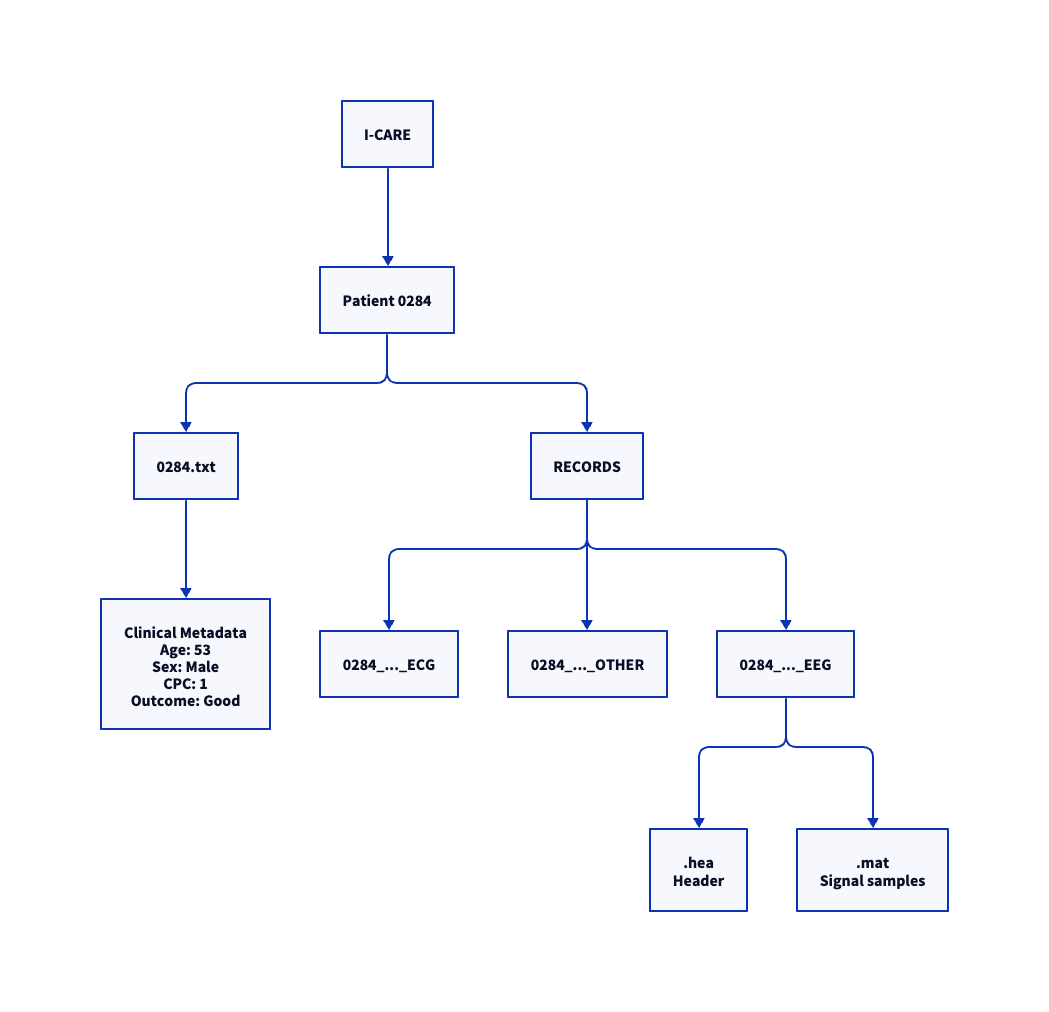

# Metadata Clinica

## **1. Adquisición e Integración de los Datos**
---
Proporcione únicamente el código de Python necesario para descargar el conjunto de datos que será utilizado en el proyecto. Si es necesario, realice operaciones de adquisición e integración del conjunto de datos.

**Fuente de los datos**

I-CARE: International Cardiac Arrest REsearch consortium Database, v2.1 (14 dic. 2023), disponible en PhysioNet bajo licencia CC BY-NC-SA 4.0.

DOI: https://doi.org/10.13026/m33r-bj81

Cita: Amorim, E., Zheng, W., Lee, J. W., et al. (2023). I-CARE: International Cardiac Arrest REsearch consortium Database (version 2.1). PhysioNet. https://doi.org/10.13026/m33r-bj81

Este conjunto de datos se divide en dos. El primero referente a los datos clínicos y el segundo a los datos correspondientes a las señales como se muestra a continuación

## Adquisición e Integración de los Datos: Clinical Metadata

In [ ]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd

BASE_URL = "https://physionet.org/files/i-care/2.1"
RECORDS_URL = f"{BASE_URL}/RECORDS"

# Sesión con reintentos automáticos para errores transitorios del servidor
# (502/503/504) y fallos de conexión, en vez de que todo el proceso se caiga
# por un solo paciente como pasó con el 0419.
session = requests.Session()
retries = Retry(
    total=5,
    backoff_factor=1.5,
    status_forcelist=[502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retries))

# 1. Índice de pacientes
response = session.get(RECORDS_URL, timeout=30)
response.raise_for_status()
records = response.text.splitlines()
patient_ids = [record.strip("/").split("/")[-1] for record in records]
print("Número de pacientes encontrados:", len(patient_ids))

# 2. Descarga y parseo del archivo clínico de cada paciente
patients = []
failed_patients = []

for i, pid in enumerate(patient_ids, start=1):
    url = f"{BASE_URL}/training/{pid}/{pid}.txt"
    try:
        response = session.get(url, timeout=30)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Fallo definitivo en paciente {pid}: {e}")
        failed_patients.append(pid)
        continue

    data = {}
    for line in response.text.strip().splitlines():
        key, value = line.split(":", 1)
        data[key.strip()] = value.strip()
    patients.append(data)

    if i % 100 == 0:
        print(f"Progreso: {i}/{len(patient_ids)} pacientes descargados")

print(f"\nDescarga completa: {len(patients)} ok, {len(failed_patients)} fallidos")
assert len(failed_patients) == 0, f"Revisar pacientes fallidos: {failed_patients}"

# 3. Consolidación en un único DataFrame integrado
clinical_df = pd.DataFrame(patients)
clinical_df.to_csv("icare_clinical_data.csv", index=False)

clinical_df.head()

Número de pacientes encontrados: 607
Progreso: 100/607 pacientes descargados
Progreso: 200/607 pacientes descargados
Progreso: 300/607 pacientes descargados
Progreso: 400/607 pacientes descargados
Progreso: 500/607 pacientes descargados
Progreso: 600/607 pacientes descargados

Descarga completa: 607 ok, 0 fallidos


,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


## **2. Análisis Exploratorio de los Datos**
---

Normalmente en el análisis exploratorio, se trata de dar respuesta a los siguientes elementos:

### **2. Análisis exploratorio de los datos**
---

- ¿Cuántos registros contiene el *dataset*?
- ¿En qué formato están guardados los datos?
- ¿Qué tamaño en MB tiene el conjunto de datos?

## Analisis exploratorio de los datos: Metadata

In [ ]:
import os

print("Número de registros (pacientes):", clinical_df.shape[0])
print("Número de variables:", clinical_df.shape[1])

size_mb = os.path.getsize("icare_clinical_data.csv") / (1024 ** 2)
print(f"Tamaño del archivo CSV integrado: {size_mb:.3f} MB")

clinical_df.info()

Número de registros (pacientes): 607
Número de variables: 10
Tamaño del archivo CSV integrado: 0.023 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient           607 non-null    object
 1   Hospital          607 non-null    object
 2   Age               607 non-null    object
 3   Sex               607 non-null    object
 4   ROSC              607 non-null    object
 5   OHCA              607 non-null    object
 6   Shockable Rhythm  607 non-null    object
 7   TTM               607 non-null    object
 8   Outcome           607 non-null    object
 9   CPC               607 non-null    object
dtypes: object(10)
memory usage: 47.6+ KB


**¿Cuántos registros contiene el dataset?**
El conjunto de datos integrado (clinical_df) contiene 607 registros, uno por cada paciente incluido en el conjunto de entrenamiento público de I-CARE v2.1, y 10 variables por paciente (Patient, Hospital, Age, Sex, ROSC, OHCA, Shockable Rhythm, TTM, Outcome, CPC).

 Además, es importante distinguir esto del concepto de "registro" en las señales fisiológicas: según la documentación oficial, el dataset completo de I-CARE contiene 80,809 segmentos de grabación (EEG, ECG y otros) distribuidos entre esos mismos 607 pacientes. Por ejemplo, el paciente 0284 por sí solo tiene 255 registros fisiológicos. Este análisis se enfoca en los 607 registros clínicos (uno por paciente); el estudio detallado de los segmentos de señal fisiológica se abordará sobre una muestra representativa en una fase posterior.

**¿En qué formato están guardados los datos?**
Originalmente, la información clínica de cada paciente se encuentra en PhysioNet como un archivo de texto plano individual (.txt), con una estructura de pares Variable: Value. En este notebook esos 607 archivos se descargaron, se transformaron y se integraron en un DataFrame de pandas, la cual se exportó como un archivo .csv (icare_clinical_data.csv).

Las señales fisiológicas (EEG, ECG) vienen en formato WFDB (el estándar de PhysioNet), representadas en dos archivos por registro: un header en texto plano (.hea, con metadatos como canales y frecuencia de muestreo) y los valores numéricos de la señal en formato binario MATLAB (.mat).

**¿Qué tamaño en MB tiene el conjunto de datos?**
El archivo icare_clinical_data.csv resultante de la integración pesa aproximadamente 0.023 MB (23 KB). Este tamaño reducido corresponde únicamente a los metadatos clínicos y demográficos de los pacientes; no incluye las señales fisiológicas de EEG/ECG (formato WFDB), que representan un volumen considerablemente mayor (del orden de 1.5 TB en conjunto) y se abordarán de manera complementaria sobre una muestra reducida de pacientes.


### **3. Análisis estadístico descriptivo**
---

Describa el conjunto de datos por medio de estadística descriptiva, aportando interpretaciones precisas que ayuden a entender los datos.

## Análisis estadístico descriptivo: Clinical Metadata

Como se identificó en la sección 2.1, todas las columnas de clinical_df quedaron con tipo de dato object al provenir de archivos de texto plano, incluidas las variables que conceptualmente son numéricas (Age, ROSC, TTM). Antes de calcular cualquier medida estadística descriptiva (media, mediana, desviación estándar, etc.), es necesario convertir explícitamente estas columnas a tipo numérico; de lo contrario, pandas las trataría como texto y no permitiría operar sobre ellas correctamente.



Verificamos qué valores originales (en texto) hacen que la conversión a número falle, antes de decidir hacer la conversión

In [ ]:
numeric_cols = ["Age", "ROSC", "TTM"]
for col in numeric_cols:
    valores_no_numericos = clinical_df.loc[
        pd.to_numeric(clinical_df[col], errors="coerce").isna(), col
    ].unique()
    print(f"{col}: valores no numéricos encontrados -> {valores_no_numericos}")

Age: valores no numéricos encontrados -> ['nan']
ROSC: valores no numéricos encontrados -> ['nan']
TTM: valores no numéricos encontrados -> ['nan']


Age: valores no numéricos encontrados -> ['nan'] significa que en la columna Age, el único valor que no se pudo convertir directamente a número es el texto "nan", es decir, algunos pacientes no tienen la edad registrada, y ese vacío quedó guardado como la palabra "nan" en vez de quedar realmente vacío. Lo mismo aplica para ROSC y TTM: en ambas, el único valor problemático es también "nan".


 Dado que se trata de un único caso identificado y controlado, se procede a realizar la conversión definitiva de estas columnas a tipo numérico mediante pd.to_numeric() con el parámetro errors="coerce", el cual transformará ese texto "nan" en valores nulos (NaN) reales, reconocidos como tal por pandas.

In [ ]:
for col in numeric_cols:
    clinical_df[col] = pd.to_numeric(clinical_df[col], errors="coerce")

clinical_df[numeric_cols].dtypes

,0
Age,float64
ROSC,float64
TTM,float64


**Estadística descriptiva de las variables numéricas:**

In [ ]:

# Estadística descriptiva de las variables numéricas
clinical_df[numeric_cols].describe()

,Age,ROSC,TTM
count,606.000000,303.000000,509.000000
mean,61.168317,23.267327,33.359528
std,15.650355,18.794052,0.975291
min,16.000000,1.000000,33.000000
25%,52.000000,10.000000,33.000000
50%,63.000000,19.000000,33.000000
75%,72.000000,30.000000,33.000000
max,90.000000,111.000000,36.000000


**Interpretación de la estadística descriptiva (variables numéricas)**

**Edad (`Age`):** el conjunto de datos tiene información de edad para 606 de los 607 pacientes (solo 1 valor faltante, equivalente al 0.16%). La edad promedio es de 61.2 años (desviación estándar de 15.7), con un rango que va de 16 a 90 años. La mitad de los pacientes tiene entre 52 y 72 años (rango intercuartílico), y la mediana es 63 años. Esto confirma que la población está compuesta mayoritariamente por adultos de mediana edad y adultos mayores, consistente con la epidemiología típica del paro cardíaco. Es importante aclarar que el valor máximo (90) no debe leerse como una edad exacta ya que según la documentación oficial de I-CARE, por anonimización todo paciente mayor de 89 años queda registrado con Age = 90, por lo que este valor es en realidad un tope de censura ("90 años o más") y puede generar una acumulación artificial de casos en ese punto que no representa la edad real de esos pacientes.

**Manejo de temperatura dirigido (`TTM`):** 509 de los 607 pacientes tienen este dato registrado (98 "faltantes", 16.1%). Lo más llamativo es la desviación estándar extremadamente baja (0.98), con la mediana, el percentil 25 y el percentil 75 coincidiendo exactamente en 33, y un máximo de 36. Esto indica que TTM no se comporta como una variable verdaderamente continua, sino que refleja un protocolo clínico con valores objetivo discretos (33 °C o 36 °C). Además, según la documentación oficial de I-CARE, el valor NaN en TTM no representa un dato que no se logró capturar, sino que está codificado explícitamente como "no TTM": ese 16.1% corresponde a pacientes a quienes no se les aplicó manejo de temperatura dirigido, no a información desconocida.

**Tiempo hasta el retorno de circulación espontánea (`ROSC`):** esta variable presenta una cantidad considerable de datos faltantes: solo 303 de los 607 pacientes tienen este valor registrado (304 faltantes, equivalente al 50.1% del total). Entre quienes sí tienen el dato, el tiempo promedio hasta ROSC es de 23.3 minutos (desviación estándar de 18.8), con un rango muy amplio (de 1 a 111 minutos) y una mediana de 19 minutos. A diferencia de TTM, la documentación no indica un significado especial para los valores faltantes de ROSC, por lo que aquí sí se trata de datos genuinamente no capturados. Dada la alta proporción de valores faltantes, cualquier análisis posterior con esta variable debe interpretarse con cuidado, ya que la mitad de la información no está disponible.



En conjunto, estas tres variables muestran patrones de "valores faltantes" muy distintos entre sí, y no todos son comparables: en Age el faltante es mínimo (0.16%) y real; en ROSC es alto (50.1%) y también real, por lo que su ausencia limita el análisis; en TTM, en cambio, el 16.1% no es un dato perdido sino una categoría clínica válida ("sin TTM") documentada explícitamente por los autores del dataset. Esta distinción deberá tenerse en cuenta explícitamente al decidir estrategias de imputación en la fase de Preparación de los Datos: Age y ROSC son candidatas a imputación o exclusión según el caso, mientras que TTM debería conservar su NaN (o recodificarse como categoría "Sin TTM") en lugar de imputarse.

In [ ]:
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(clinical_df[col].value_counts(dropna=False))


--- Sex ---
Sex
Male      417
Female    187
nan         3
Name: count, dtype: int64

--- Hospital ---
Hospital
A    261
B    120
D     83
E     74
F     69
Name: count, dtype: int64

--- OHCA ---
OHCA
True     442
False    124
nan       41
Name: count, dtype: int64

--- Shockable Rhythm ---
Shockable Rhythm
True     297
False    278
nan       32
Name: count, dtype: int64

--- Outcome ---
Outcome
Poor    382
Good    225
Name: count, dtype: int64

--- CPC ---
CPC
5    353
1    181
2     44
3     20
4      9
Name: count, dtype: int64


**Interpretación de la estadística descriptiva (variables categóricas)**

**Sexo (`Sex`):** la población es mayoritariamente masculina (417 hombres, 68.7%; 187 mujeres, 30.8%), con solo 3 registros (0.5%) sin este dato. Esta proporción es consistente con la mayor incidencia de paro cardíaco reportada en hombres en la literatura clínica.

**Hospital (`Hospital`):** se observan 5 códigos de institución en los datos (A, B, D, E, F). Según la documentación oficial de I-CARE, aunque el consorcio está formado por 7 hospitales, los identificadores del conjunto público de entrenamiento solo cubren las letras A a F (6 códigos posibles). La distribución además es muy desigual ya que el hospital A concentra el 43.0% de todos los pacientes (261 de 607), mientras que F aporta solo el 11.4% (69 pacientes). Esta fuerte concentración en un solo centro refuerza la necesidad de tratar Hospital como una posible fuente de heterogeneidad.

**Paro cardíaco extrahospitalario (`OHCA`):** el 72.8% de los pacientes (442) sufrió el paro fuera del hospital, frente a un 20.4% que lo sufrió dentro del hospital (124), con un 6.8% de datos faltantes (41 pacientes).

**Ritmo inicial desfibrilable (`Shockable Rhythm`):** esta variable está prácticamente balanceada entre sus dos categorías (48.9% True, 45.8% False), con un 5.3% de valores faltantes (32 pacientes).

**Desenlace neurológico (`Outcome`):** la variable objetivo del proyecto muestra un desbalance moderado: el 62.9% de los pacientes (382) tuvo un desenlace Poor, frente a un 37.1% (225) con desenlace Good. Este desbalance deberá tenerse en cuenta en el análisis inferencial y en el modelado estadístico posterior, ya que puede afectar la interpretación de comparaciones entre grupos.

**Cerebral Performance Category (`CPC`):** la distribución es marcadamente bimodal: ya que el 58.2% de los pacientes (353) tiene CPC = 5 (muerte) y el 29.8% (181) tiene CPC = 1 (función cerebral conservada), mientras que las categorías intermedias (CPC 2, 3 y 4) concentran en conjunto solo el 12.0% de los casos. Esto confirma, con evidencia numérica, que los desenlaces post-paro cardíaco tienden a ubicarse en los extremos de la escala más que en niveles intermedios de discapacidad.



**Verificación de consistencia entre `CPC` y `Outcome`**

| CPC | Significado | Pacientes | Outcome esperado |
|---|---|---|---|
| 1 | Función cerebral normal | 181 | Good |
| 2 | Discapacidad neurológica moderada | 44 | Good |
| 3 | Discapacidad neurológica severa | 20 | Poor |
| 4 | Estado vegetativo | 9 | Poor |
| 5 | Muerte | 353 | Poor |

Sumando por grupo:
- Good esperado: 181 + 44 = **225**
- Poor esperado: 20 + 9 + 353 = **382**

Estos totales coinciden exactamente con el conteo real de Outcome (225 Good, 382 Poor), confirmando que la variable fue construida correctamente a partir de CPC, sin inconsistencias.

In [ ]:
comparacion = clinical_df.groupby("Outcome")[numeric_cols].describe().T
comparacion

Outcome           Good        Poor
Age  count  224.000000  382.000000
     mean    57.549107   63.290576
     std     13.781033   16.296043
     min     19.000000   16.000000
     25%     48.750000   54.250000
     50%     58.000000   66.000000
     75%     67.250000   75.000000
     max     88.000000   90.000000
ROSC count   85.000000  218.000000
     mean    19.282353   24.821101
     std     17.091917   19.231314
     min      1.000000    1.000000
     25%      8.000000   11.250000
     50%     15.000000   20.000000
     75%     25.000000   30.000000
     max    111.000000  100.000000
TTM  count  194.000000  315.000000
     mean    33.371134   33.352381
     std      0.990311    0.967441
     min     33.000000   33.000000
     25%     33.000000   33.000000
     50%     33.000000   33.000000
     75%     33.000000   33.000000
     max     36.000000   36.000000

In [ ]:
pd.crosstab(clinical_df['Outcome'], clinical_df['TTM'], dropna=False)

TTM,33.0,36.0,NaN
Outcome,,,
Good,170,24,31
Poor,278,37,67


**Comparación descriptiva entre grupos de desenlace (`Age`, `ROSC`, `TTM`)**

**Edad (`Age`):** Los pacientes con desenlace Poor tienden a ser mayores que los de desenlace Good, y esta diferencia se mantiene en toda la distribución:

- **Media:** 63.3 años (Poor) vs. 57.5 años (Good) — casi 6 años de diferencia.
- **Mediana:** 66 años (Poor) vs. 58 años (Good).
- **Rango intercuartílico (IQR):** 54-75 años (Poor) vs. 49-67 años (Good) — el rango completo está desplazado hacia edades mayores.

Esto es consistente con la literatura clínica, que identifica la edad como uno de los factores pronósticos más importantes tras un paro cardíaco: a mayor edad, menor probabilidad de recuperación neurológica favorable.

**Tiempo hasta el retorno de circulación espontánea (`ROSC`):** entre quienes tienen el dato registrado, los pacientes Poor tardaron en promedio más tiempo en recuperar circulación espontánea (24.8 minutos vs. 19.3 minutos en Good), con una mediana de 20 minutos frente a 15. Esto también es clínicamente esperable: cuanto más tiempo pasa el cerebro sin circulación adecuada, mayor es el daño hipóxico y peor el pronóstico neurológico. Vale la pena señalar además que la proporción de datos faltantes en ROSC no es igual entre los dos grupos: en Good falta el dato en 140 de 225 pacientes (62.2%), mientras que en Poor falta en 164 de 382 (42.9%). Esta diferencia en la tasa de datos faltantes entre grupos debe tenerse en cuenta más adelante.

**Manejo de temperatura dirigido (`TTM`):**

El cruce de Outcome con TTM (incluyendo los NaN como categoría "sin TTM") confirma y completa lo señalado en la comparación de medias: dentro de cada grupo, la gran mayoría de los pacientes que sí recibieron manejo de temperatura fueron tratados a 33 °C, y esa proporción es prácticamente idéntica entre grupos — 87.6% de los pacientes Good con TTM (170 de 194) estuvieron a 33 °C frente a un 12.4% a 36 °C; en Poor la proporción es de 88.3% (278 de 315) a 33 °C y 11.7% a 36 °C. Es decir, entre quienes recibieron el protocolo, la elección de la temperatura objetivo (33 °C vs. 36 °C) no muestra una relación apreciable con el desenlace neurológico.

Donde sí aparece una diferencia es en si el paciente recibió o no el protocolo: el 13.8% de los pacientes Good no tuvo TTM (31 de 225) frente al 17.5% de los Poor (67 de 382). Aunque la diferencia es moderada, conviene interpretarla con cautela ya que no necesariamente significa que omitir el TTM cause peor desenlace, sino que probablemente ambas cosas están relacionadas con la gravedad inicial del paciente.

En conjunto, Age y ROSC muestran una relación clara y clínicamente coherente con el desenlace neurológico —peores desenlaces asociados a pacientes de mayor edad y con tiempos de reanimación más largos—, mientras que `TTM`, dada su naturaleza casi categórica, requiere un análisis distinto al de una variable continua para evaluar su relación con `Outcome`.

In [ ]:
import matplotlib.pyplot as plt


## **Distribución de Outcome**

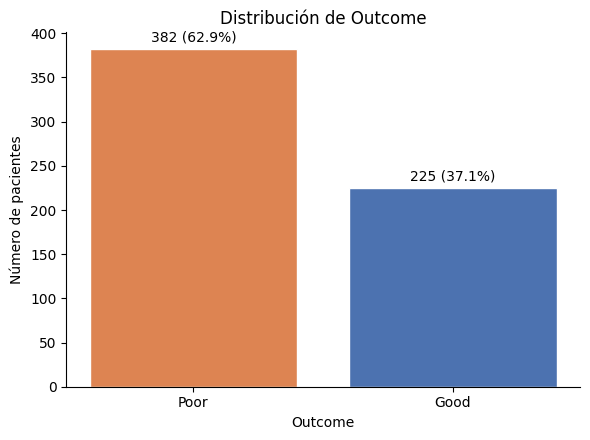

In [ ]:
counts = clinical_df['Outcome'].value_counts()
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(counts.index, counts.values, color=['#DD8452', '#4C72B0'], edgecolor='white')

for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())} ({pct:.1f}%)', ha='center', va='bottom')

ax.set_title('Distribución de Outcome')
ax.set_xlabel('Outcome')
ax.set_ylabel('Número de pacientes')
ax.tick_params(axis='x', rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

- El dataset está desbalanceado: hay más pacientes con desenlace Poor (aprox. 383, 63%) que con Good (aprox. 224, 37%).
- Esto es clínicamente esperable en el contexto de paro cardíaco extrahospitalario, donde la mayoría de los pacientes no logra una recuperación neurológica favorable.

## **Histograma de `Age` y `ROSC`**

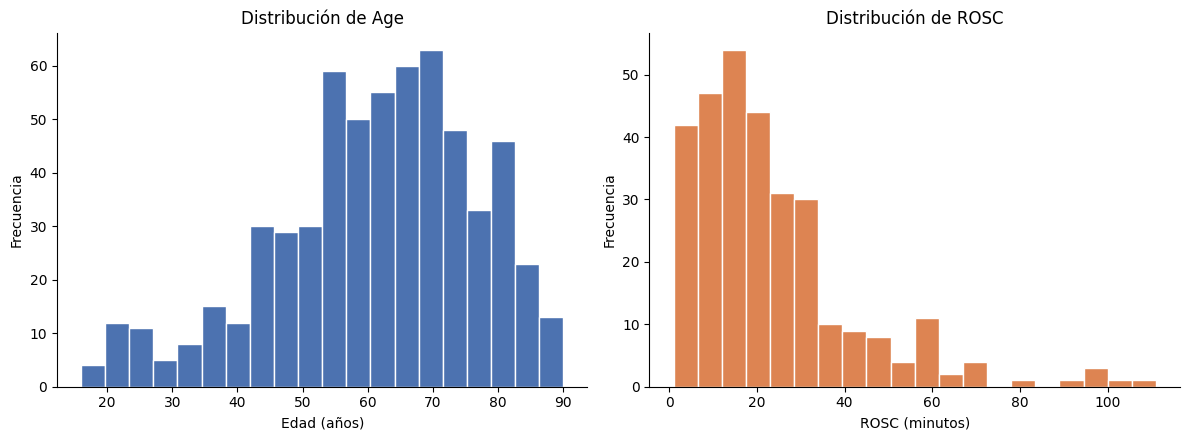

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

age = pd.to_numeric(clinical_df['Age'], errors='coerce').dropna()
rosc = pd.to_numeric(clinical_df['ROSC'], errors='coerce').dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(age, bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(rosc, bins=20, color='#DD8452', edgecolor='white')
axes[1].set_title('Distribución de ROSC')
axes[1].set_xlabel('ROSC (minutos)')
axes[1].set_ylabel('Frecuencia')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
(clinical_df['Age'] >= 65).mean() * 100
#qué porcentaje de pacientes tiene 65 años o más

np.float64(47.1169686985173)

In [ ]:
clinical_df['Age'].value_counts().sort_index(ascending=False).head(10)

,count
Age,
90.0,7
89.0,1
88.0,2
87.0,3
86.0,3
85.0,7
84.0,4
83.0,9
82.0,11




La distribución de `Age` (azul) es asimétrica hacia la izquierda: la mayor concentración de pacientes está entre 55 y 80 años, con el pico más alto alrededor de los 65-75 años, y una cola que se extiende hacia edades menores (20-50 años) en menor proporción. Esto confirma visualmente lo que ya se había descrito con la mediana (63 años) y el rango intercuartílico (52-72) por lo que la población está compuesta principalmente por adultos mayores.

Vale la pena revisar si la barra final (cercana a 90) muestra un corte abrupto en vez de una disminución gradual, ya que eso sería la evidencia visual del tope de censura en `Age = 90` que se documentó antes.

La distribución de `ROSC` (naranja) tiene la forma opuesta: es fuertemente asimétrica hacia la derecha, con la mayoría de los pacientes concentrados en tiempos cortos (menos de 20-25 minutos) y una cola larga y poco poblada que se extiende hasta más de 100 minutos. Esto es coherente con lo esperado clínicamente: la mayoría de los pacientes recuperan circulación espontánea relativamente rápido, mientras que un grupo pequeño requiere reanimaciones mucho más prolongadas.



## **Interpretación de asimetría (skew) y curtosis (kurt) para Age y ROSC:**

In [ ]:
clinical_df[['Age', 'ROSC']].skew()   # asimetría


,0
Age,-0.592279
ROSC,1.846755


In [ ]:
clinical_df[['Age', 'ROSC']].kurt()   # curtosis

,0
Age,0.007445
ROSC,4.213143


**Age:**

- Asimetría = -0.59 (moderadamente negativa): la distribución tiene una cola ligeramente más larga hacia la izquierda (edades bajas), lo cual es coherente con el histograma. la mayoría de los pacientes se concentra entre 55-75 años, con una cola más extendida hacia edades jóvenes que hacia edades muy avanzadas.
- Curtosis = 0.007 indica una forma mesocúrtica, es decir, muy similar a una distribución normal en cuanto a qué tan puntiaguda es o qué tan pesadas son sus colas.

**ROSC:**

- Asimetría = 1.85 (fuertemente positiva): confirma numéricamente que la mayoría de los pacientes tiene tiempos de ROSC bajos, con una cola larga hacia la derecha por los casos de reanimaciones prolongadas (hasta 100+ minutos).
- Curtosis = 4.21 distribución leptocúrtica, con un pico más concentrado alrededor de los valores bajos y colas más pesadas de lo que tendría una distribución normal, coincidiendo con los múltiples outliers vistos en el boxplot de ROSC.

**En conjunto:** Age se comporta de forma razonablemente simétrica y cercana a lo normal, mientras que ROSC está claramente sesgada a la derecha y tiene colas pesadas. Esto es importante porque estadísticos como la media son menos representativos para ROSC (la mediana es más robusta en este caso), y explica por qué se observaron tantos outliers marcados en su boxplot.

## **Distribución de Age Y ROSC por Outcome**

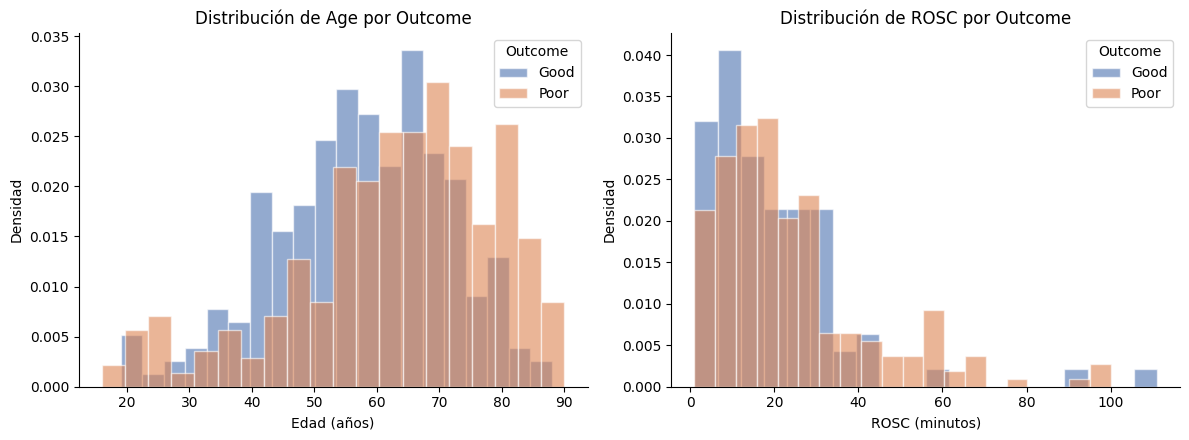

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for outcome, color in zip(['Good', 'Poor'], ['#4C72B0', '#DD8452']):
    age_data = clinical_df.loc[clinical_df['Outcome'] == outcome, 'Age'].dropna()
    axes[0].hist(age_data, bins=20, alpha=0.6, color=color, edgecolor='white',
                 density=True, label=outcome)

    rosc_data = clinical_df.loc[clinical_df['Outcome'] == outcome, 'ROSC'].dropna()
    axes[1].hist(rosc_data, bins=20, alpha=0.6, color=color, edgecolor='white',
                 density=True, label=outcome)

axes[0].set_title('Distribución de Age por Outcome')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Densidad')
axes[0].legend(title='Outcome')

axes[1].set_title('Distribución de ROSC por Outcome')
axes[1].set_xlabel('ROSC (minutos)')
axes[1].set_ylabel('Densidad')
axes[1].legend(title='Outcome')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Age:

La distribución de Good se concentra más entre los 55-70 años, con su pico más alto justo ahí (~0.034).
La distribución de Poor está desplazada hacia edades mayores: tiene más densidad relativa en el rango de 70-85 años, y una cola que llega hasta cerca de 90 años que prácticamente no existe en Good.
Ambos grupos comparten un pequeño grupo de pacientes jóvenes (20-30 años), pero es un poco más marcado en Poor.
En conjunto, esto confirma que a mayor edad, mayor proporción relativa de desenlace Poor.

ROSC:

Ambos grupos tienen su mayor densidad en tiempos cortos (0-15 min), pero Good tiene un pico más pronunciado y concentrado ahí (~0.04) y cae más rápido después de los 20-30 min.
Poor tiene una distribución más "aplanada" y con cola más larga: mantiene densidad notable hasta los 40-70 min, y es casi el único grupo presente en los tramos de 50-100+ min.
Esto sugiere que cuanto más tiempo tarda un paciente en recuperar circulación espontánea, más probable es que el desenlace sea Poor.

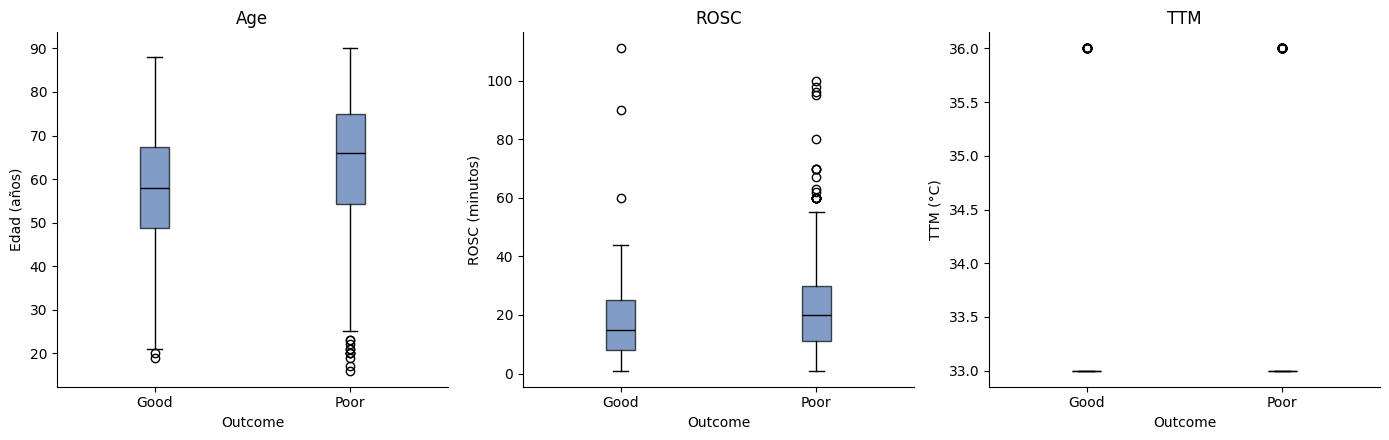

In [ ]:
cols = ['Age', 'ROSC', 'TTM']
ylabels = {'Age': 'Edad (años)', 'ROSC': 'ROSC (minutos)', 'TTM': 'TTM (°C)'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, col in zip(axes, cols):
    good = clinical_df.loc[clinical_df['Outcome'] == 'Good', col].dropna()
    poor = clinical_df.loc[clinical_df['Outcome'] == 'Poor', col].dropna()

    bp = ax.boxplot([good, poor], tick_labels=['Good', 'Poor'], patch_artist=True,
                     medianprops=dict(color='black'))
    for box in bp['boxes']:
        box.set_facecolor('#4C72B0')
        box.set_alpha(0.7)

    ax.set_title(col)
    ax.set_xlabel('Outcome')
    ax.set_ylabel(ylabels[col])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Age (Edad):**

- Los pacientes con Outcome Poor tienden a ser mayores: la mediana de edad es de 66 años, frente a 58 años en el grupo Good. El rango intercuartílico también está desplazado hacia arriba en Poor (54-75 años) en comparación con Good (49-67 años).
- Ambos grupos presentan outliers de pacientes jóvenes (<20 años), aunque son más marcados en Poor.

**ROSC (tiempo hasta retorno de circulación espontánea):**

- La mediana es más alta en Poor (≈20 min) que en Good (≈15 min), y el rango intercuartílico también está desplazado hacia valores mayores (11-30 vs. 7-25).
- Ambos grupos tienen outliers de reanimaciones muy prolongadas (60-110 min), pero en Poor hay más outliers y llegan a valores más altos (cerca de 100 min) es decir, cuanto más tiempo tardó el paciente en recuperar circulación espontánea, más frecuente fue el desenlace desfavorable. Esto es clínicamente coherente: a mayor tiempo de paro sin circulación, mayor daño cerebral por falta de oxígeno (isquemia), lo que reduce la probabilidad de recuperación neurológica.

**TTM (manejo de temperatura dirigido):**

- Aquí el patrón es distinto: la caja está prácticamente aplanada en 33°C para ambos grupos (Good y Poor), es decir, la gran mayoría de los pacientes que recibieron TTM fueron tratados a 33°C, sin importar el desenlace.
- Solo aparece un outlier en 36°C en cada grupo.
- En otras palabras, TTM no muestra diferencia visible entre Good y Poor — el protocolo de temperatura aplicado no parece discriminar el desenlace, al menos en este gráfico. (Recuerda que este boxplot solo incluye a los pacientes que sí recibieron TTM, ya que los NaN —"sin TTM"— se excluyeron con `dropna()`.)

## **Distribución de pacientes por Hospital**

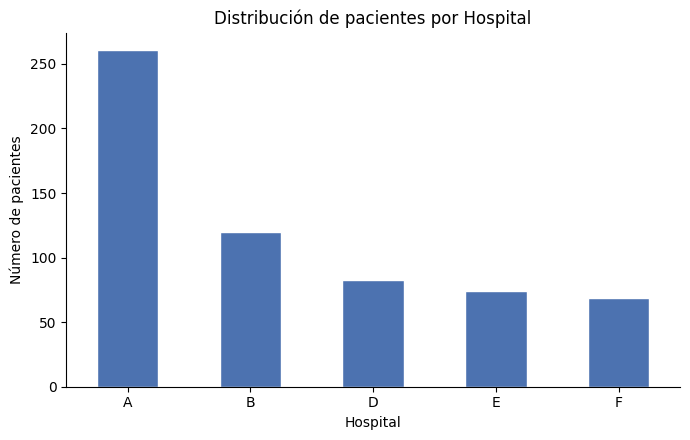

In [ ]:
ax = clinical_df['Hospital'].value_counts().plot.bar(color='#4C72B0', edgecolor='white', figsize=(7, 4.5))

ax.set_title('Distribución de pacientes por Hospital')
ax.set_xlabel('Hospital')
ax.set_ylabel('Número de pacientes')
ax.tick_params(axis='x', rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

- El Hospital A concentra la mayor parte de los pacientes (aprox. 260, alrededor del 43% del total), muy por encima del resto.
- El Hospital B es el segundo con más pacientes (aprox. 120, 20%), y luego D, E y F tienen participaciones más parecidas entre sí y bastante menores (entre 70 y 82 pacientes cada uno, 11-14%).
- La distribución es claramente desigual entre hospitales: no es una muestra balanceada por sitio, sino que un solo centro (A) aporta casi la mitad de los datos.
- Se confirma lo que ya habíamos revisado en la documentación oficial de PhysioNet: no aparece el código C — de los 7 hospitales del consorcio original, el conjunto público de entrenamiento solo incluye 6 (A, B, D, E, F), ya que uno fue excluido de esta versión pública del dataset.
- Vale la pena mencionar esto como una posible fuente de heterogeneidad: al estar tan concentrados los datos en el Hospital A, cualquier diferencia en protocolos clínicos, criterios de TTM o características de la población atendida en ese centro podría influir de forma desproporcionada en los patrones generales observados en el dataset.

## **Gráficos de barras para Sex, OHCA y Shockable Rhythm**

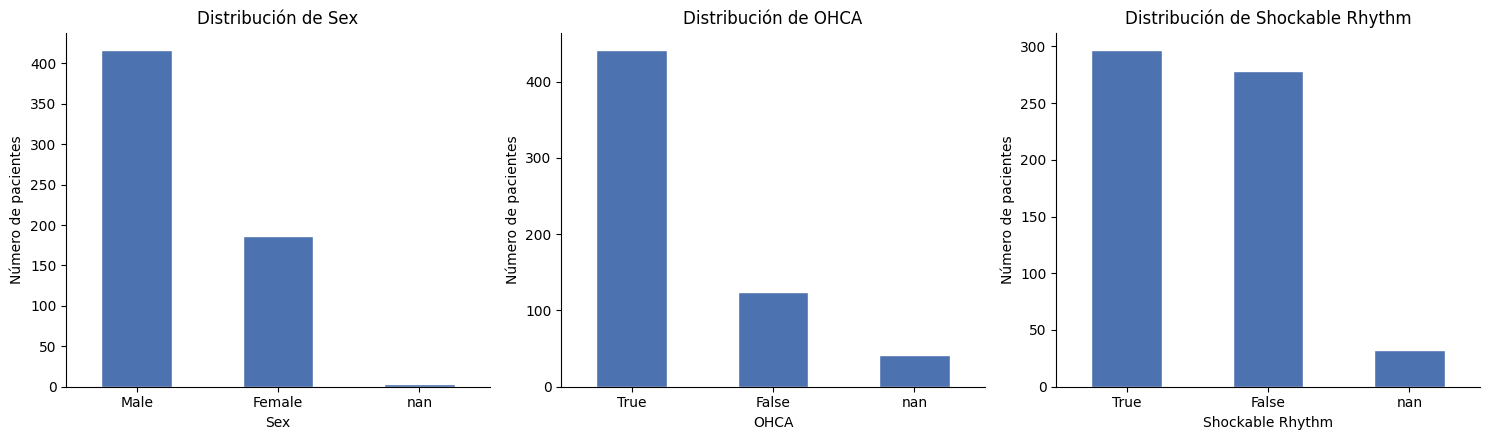

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

variables = {'Sex': axes[0], 'OHCA': axes[1], 'Shockable Rhythm': axes[2]}

for col, ax in variables.items():
    clinical_df[col].value_counts().plot.bar(ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Número de pacientes')
    ax.tick_params(axis='x', rotation=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Sex:**

- La mayoría de los pacientes son hombres (aprox. 415, 68%), frente a mujeres (aprox. 185, 30%), el dataset está claramente desbalanceado por sexo.
- Hay una fracción muy pequeña de valores "nan" (menos del 1%), un dato faltante casi insignificante en proporción.

**OHCA (paro cardíaco extrahospitalario):**

- La gran mayoría de los casos ocurrió fuera del hospital (True, aprox. 438, 72%), frente a paros intrahospitalarios (False, aprox. 125, 21%).
- Aquí la categoría "nan" ya es más notoria (aprox. 44 pacientes, 7%) — vale la pena cuantificarla en la sección de calidad de datos, ya que no es un porcentaje despreciable.
- Esto es coherente con el enfoque del dataset I-CARE, centrado principalmente en paro cardíaco extrahospitalario.

**Shockable Rhythm:**

- Está bastante equilibrado entre ritmo desfibrilable (True, aprox. 295, 49%) y no desfibrilable (False, aprox. 278, 46%) — a diferencia de Sex y OHCA, aquí no hay un predominio tan marcado de una categoría.
- También tiene un grupo de "nan" (aprox. 30 pacientes, 5%) a documentar en calidad de datos.

**En conjunto:** el dataset muestra un sesgo claro hacia pacientes hombres y hacia paros extrahospitalarios, mientras que el tipo de ritmo cardíaco está más balanceado. Los valores "nan" en OHCA y Shockable Rhythm son proporciones que sí ameritan revisión en la sección de calidad de datos, mientras que en Sex son prácticamente insignificantes.


Se observa una pequeña categoría "nan" en Sex, OHCA y Shockable Rhythm, correspondiente a valores faltantes codificados como texto en vez de como NaN real. Este hallazgo se detalla y corrige en la sección de Calidad de datos.

In [ ]:
import matplotlib.pyplot as plt

corr = clinical_df[['Age', 'ROSC', 'TTM']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Matriz de correlación')
fig.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
clinical_df[['Age', 'ROSC', 'TTM']].corr()

Age vs. ROSC = -0.12: correlación negativa muy débil. Sugiere una leve tendencia a que pacientes de mayor edad tengan tiempos de ROSC ligeramente menores, pero el valor es tan bajo que prácticamente no hay relación lineal significativa entre estas dos variables.
Age vs. TTM = 0.05: correlación prácticamente nula. No hay relación lineal apreciable entre la edad del paciente y la temperatura objetivo usada en el manejo de temperatura.
ROSC vs. TTM = -0.05: igual que el caso anterior, correlación esencialmente nula.

En conjunto: ninguna de las tres variables numéricas muestra una correlación lineal fuerte entre sí — todos los valores están muy cerca de 0, lo que indica que Age, ROSC y TTM se comportan de forma bastante independiente entre ellas.

In [ ]:

clinical_df['Sex_num'] = (clinical_df['Sex'] == 'Male').astype(int)
clinical_df['OHCA_num'] = (clinical_df['OHCA'] == 'True').astype(int)
clinical_df['ShockableRhythm_num'] = (clinical_df['Shockable Rhythm'] == 'True').astype(int)

cols = ['Age', 'ROSC', 'TTM', 'Sex_num', 'OHCA_num', 'ShockableRhythm_num', 'Outcome_num']
corr_ext = clinical_df[cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_ext, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr_ext.iloc[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Matriz de correlación extendida')
fig.colorbar(im)
plt.tight_layout()
plt.show()



- **Shockable Rhythm vs. Outcome_num = -0.37** la correlación más fuerte de toda la matriz es negativa, y como ShockableRhythm_num=1 significa que el paciente tuvo un ritmo desfibrilable (ej. fibrilación ventricular) y Outcome_num=1 significa Poor, esta correlación negativa indica que tener un ritmo desfibrilable se asocia con menor probabilidad de desenlace Poor, es decir, con mejor pronóstico.
- **OHCA vs. Shockable Rhythm = 0.28**: correlación positiva moderada sugiere que los paros ocurridos fuera del hospital (OHCA) están más asociados a presentar un ritmo desfibrilable que los ocurridos dentro del hospital.
- **TTM vs. OHCA = -0.26**: sugiere que los pacientes con paro extrahospitalario tienden más hacia TTM en 33°C, mientras que los de paro intrahospitalario tienden más hacia 36°C, probablemente reflejando diferencias en protocolos de manejo según el contexto del paro.
- **Age y ROSC vs. Outcome** (0.18 y 0.13): siguen siendo las correlaciones débiles ya identificadas, pero en este contexto se ven más débiles que la de Shockable Rhythm, lo que sugiere que el tipo de ritmo cardíaco es, de las variables disponibles, la que más se relaciona linealmente con el desenlace.
- El resto de las combinaciones (Sex con cualquier variable, TTM con la mayoría) son cercanas a 0, sin relación lineal relevante.

En conclusión, esta matriz extendida muestra que Age y ROSC se relacionan (débilmente) con el desenlace,y que Shockable Rhythm muestra la asociación más fuerte de todas las variables analizadas, un hallazgo clínicamente relevante dentro del análisis descriptivo.

### **4. Calidad de los datos**
---

- ¿Se detecta la ausencia de datos, la presencia de datos erróneos o la existencia de datos de baja calidad en el conjunto?
- ¿Se identifican registros con datos ilegibles o con dificultades de codificación durante la revisión del conjunto de datos?
- ¿Se observa una diversidad de formatos en el conjunto de datos que pueda dificultar su consistencia o comprensión?
- ¿Se identificaron y abordaron posibles problemas, como valores atípicos, duplicados o datos faltantes?

#### **4.1 Ausencia de datos y valores faltantes ocultos**

Tal como se identificó, algunas variables numéricas (`Age`, `ROSC`, `TTM`) contenían el string `'nan'` que fue convertido a `NaN` numérico. A continuación se cuantifican los valores faltantes reales en cada columna. Observamos que `ROSC` y `TTM` tienen una proporción significativa de valores ausentes, mientras que otras variables categóricas también presentan un bajo porcentaje de nulos.

In [ ]:
print(clinical_df.isnull().sum())

In [ ]:
for col in ['Sex', 'OHCA', 'Shockable Rhythm']:
    clinical_df[col] = clinical_df[col].replace('nan', pd.NA)

print(clinical_df.isnull().sum())

**Valores faltantes ocultos**

Al ejecutar `clinical_df.isnull().sum()` por primera vez, las columnas `Sex`, `OHCA` y `Shockable Rhythm` mostraban 0 valores nulos, aunque ya se había identificado visualmente (en los gráficos de barras) que sí tenían una pequeña categoría `"nan"`. Esto ocurría porque esos valores faltantes estaban almacenados como el **string literal `"nan"`**, no como un `NaN` real de pandas, por lo que `.isnull()` no los reconocía como datos faltantes.

Al corregir esto reemplazando el texto `"nan"` por un valor nulo real (`pd.NA`) en esas tres columnas, el conteo de valores faltantes cambió de 0 a los valores reales:

- **Sex:** 3 valores faltantes
- **OHCA:** 41 valores faltantes
- **Shockable Rhythm:** 32 valores faltantes

Este hallazgo confirma la importancia de verificar no solo la cantidad de `NaN` reportada por pandas, sino también la consistencia en cómo están codificados los valores faltantes dentro de cada columna, ya que una codificación inconsistente puede ocultar datos faltantes reales y llevar a conclusiones erróneas sobre la calidad del dataset.

Con la corrección aplicada, el panorama completo de valores faltantes en el dataset queda así:

| Columna | Valores faltantes |
|---|---|
| Age | 1 |
| ROSC | 304 |
| TTM | 98 |
| Sex | 3 |
| OHCA | 41 |
| Shockable Rhythm | 32 |

**¿Se detecta la ausencia de datos, la presencia de datos erróneos o la existencia de datos de baja calidad en el conjunto?**

Sí, se identificaron varios problemas de calidad en el dataset:

**Ausencia de datos:**

- `ROSC` tiene 304 valores faltantes, `TTM` tiene 98, y `Age` tiene 1.
- Adicionalmente, se detectaron valores faltantes "ocultos" en `Sex` (3), `OHCA` (41) y `Shockable Rhythm` (32), que inicialmente no se reflejaban con `.isnull()` porque estaban codificados como el string de texto `"nan"` en vez de un valor nulo real — un problema de calidad en sí mismo, ya que puede llevar a subestimar la cantidad real de datos faltantes si no se revisa con cuidado.
- La ausencia de datos en `TTM` no es aleatoria: representa a los pacientes que no recibieron manejo de temperatura dirigido, por lo que es un faltante con significado clínico (missingness estructural), no un dato simplemente desconocido.

**Datos erróneos o de baja calidad:**

- Las columnas numéricas (`Age`, `ROSC`, `TTM`) llegaron originalmente almacenadas como texto en vez de valores numéricos, lo que impedía calcular estadísticas o graficarlas correctamente hasta convertirlas con `pd.to_numeric()`.
- `Age` presenta una acumulación anómala de pacientes exactamente en 90 años, lo que sugiere que el valor está censurado/topado (agrupando "90 años o más" en 90), en lugar de reflejar la edad exacta real de esos pacientes.
- `Hospital` solo incluye 6 de los 7 códigos del consorcio original (falta el código C), ya que el conjunto de entrenamiento público excluye uno de los hospitales — lo que es una limitación de alcance del dataset más que un error, pero relevante para interpretar correctamente la variable.

En conjunto, estos hallazgos muestran que, si bien el dataset es utilizable, requiere varias correcciones de tipo y formato antes de poder analizarse de forma confiable.

#### **4.2 Dificultades de codificación y diversidad de formatos**

Inicialmente, todas las columnas fueron importadas como tipo `object` (texto), incluyendo las que conceptualmente son numéricas o booleanas. Después de manejar los strings `'nan'` (sección 4.1) y de convertir `Age`, `ROSC` y `TTM` con `pd.to_numeric()`, verificamos que sus tipos ahora son los correctos:

In [ ]:
print(clinical_df[['Age', 'ROSC', 'TTM']].dtypes)

**¿Se identifican registros con datos ilegibles o con dificultades de codificación durante la revisión del conjunto de datos?**

No se detectaron registros con texto genuinamente ilegible o corrupto dentro de los archivos `.txt` de PhysioNet — la estructura `clave: valor` fue consistente y legible en todos los casos revisados. Las dificultades encontradas fueron de **tipificación y codificación** de los datos ya extraídos, no de legibilidad del archivo fuente:

- Las variables numéricas (`Age`, `ROSC`, `TTM`) llegaron codificadas como texto (`object`) en vez de tipo numérico, lo que impedía calcular estadísticas o graficarlas hasta convertirlas con `pd.to_numeric(errors='coerce')`.
- Las variables booleanas (`OHCA`, `Shockable Rhythm`) estaban codificadas como texto (`"True"`/`"False"`) en vez de booleanos nativos. Esto se evidenció al construir la matriz de correlación: convertirlas directamente con `.astype(int)` produjo `ValueError: invalid literal for int() with base 10: 'True'`, porque Python no puede convertir el texto `'True'` a número sin antes interpretarlo como booleano; fue necesario compararlas explícitamente contra el string (`== 'True'`) antes de convertirlas.
- Los valores faltantes no tenían una codificación consistente: en algunas columnas aparecían como `NaN` real, y en otras como el string literal `"nan"` (ver 4.1), lo que dificultaba detectarlos con `.isnull()` hasta corregirlo.

**¿Se observa una diversidad de formatos en el conjunto de datos que pueda dificultar su consistencia o comprensión?**

Sí. Además de las inconsistencias de tipificación ya descritas (numéricas y booleanas almacenadas como texto, `NaN` codificado de dos formas distintas), el dataset mezcla formatos entre variables categóricas: `Hospital` usa códigos de una sola letra (A, B, D, E, F) y notablemente **no incluye el código C**, ya que de los 7 hospitales del consorcio original, el conjunto público de entrenamiento solo incluye 6 — algo que no es evidente sin revisar la documentación oficial del dataset.

Esta diversidad de formatos no dificulta la comprensión conceptual de las variables (los nombres y significados clínicos son claros), pero sí generó fricción técnica: cada columna requirió un tratamiento de limpieza distinto antes de poder analizarla de forma consistente, y pasar por alto alguna de estas inconsistencias (como el `"nan"` de texto) puede llevar a conclusiones incorrectas sobre la calidad o el contenido real de los datos.

#### **4.3 Valores atípicos, duplicados y datos faltantes**

La variable `TTM` (Temperatura de Manejo Dirigido) presenta una distribución muy particular. Aunque es numérica, la mayoría de sus valores se concentran en 33°C y 36°C, lo que sugiere un comportamiento más cercano a una variable categórica ordinal que a una continua.

In [ ]:
print(clinical_df['TTM'].value_counts(dropna=False))

La variable `Hospital` muestra una distribución muy desigual, con una fuerte concentración de pacientes en el hospital 'A'. Esta heterogeneidad podría introducir sesgos en los análisis y es importante tenerla en cuenta.

In [ ]:
print(clinical_df['Hospital'].value_counts())

Los outliers en `Age` y `ROSC` ya se visualizaron mediante boxplots por grupo de `Outcome` y se cuantificaron con la asimetría y curtosis calculadas en la sección 3 (Análisis estadístico descriptivo). No se repiten esos gráficos aquí para no duplicar contenido; la respuesta final de esta sección retoma esos hallazgos como evidencia.

Verificamos también si existen registros de pacientes duplicados:

In [ ]:
print('Pacientes duplicados:', clinical_df.duplicated().sum())

**¿Se identificaron y abordaron posibles problemas, como valores atípicos, duplicados o datos faltantes?**

Sí, se identificaron los tres tipos de problemas mencionados:

**Valores atípicos (outliers):**

- En `ROSC` se detectaron varios pacientes con tiempos de reanimación muy prolongados (60-110 minutos), confirmados tanto en el boxplot por `Outcome` (sección 3) como en la curtosis (4.21, distribución leptocúrtica) y concentrados sobre todo en el grupo `Outcome = Poor`.
- En `Age` se observaron algunos outliers de pacientes jóvenes (menores de 20 años) en ambos grupos de `Outcome`, aunque más marcados en `Poor`.
- Adicionalmente, `Age` presenta una acumulación anómala de pacientes exactamente en 90 años, lo que sugiere un valor censurado/topado ("90 años o más" agrupado en 90) más que una edad exacta real — un caso distinto a un outlier estadístico convencional.

**Duplicados:**

- Se verificó con `clinical_df.duplicated().sum()` (arriba) que el dataset no contiene registros de pacientes duplicados.

**Datos faltantes:**

- Se cuantificaron con `.isnull().sum()` los valores faltantes reales por columna: `Age` (1), `ROSC` (304), `TTM` (98), `Sex` (3), `OHCA` (41) y `Shockable Rhythm` (32).
- Inicialmente, `Sex`, `OHCA` y `Shockable Rhythm` no mostraban sus valores faltantes porque estaban codificados como el string `"nan"` en vez de un `NaN` real; esto se corrigió reemplazándolos explícitamente antes de recalcular el conteo (ver 4.1).
- El faltante en `TTM` no es aleatorio: corresponde a pacientes que no recibieron manejo de temperatura dirigido, por lo que se trata de un missingness estructural con significado clínico, no un vacío de información desconocida.

En conjunto, los tres tipos de problemas fueron identificados mediante inspección visual (gráficos) y análisis numérico (`.isnull()`, `.duplicated()`, boxplots, curtosis), y se abordaron ajustando tipos de datos, corrigiendo la codificación de valores faltantes y documentando el origen de los valores atípicos encontrados.

### **2.4. Tipos de variables**
---

- ¿El conjunto de datos tiene una variable objetivo a estimar?, de ser así, ¿es una variable continúa o categórica?
- Analice la distribución de las etiquetas, identifique si hay desbalanceo de datos.

**Variables identificadas y su clasificación (después de la conversión de tipos):**

*   **`PatientID`**: `object` (string). Identificador único de paciente. Aunque numérico, su rol es de identificador y no se usará directamente en análisis estadísticos o modelado, sino para indexación o uniones.
*   **`Hospital`**: `object` (string). Categórica nominal. Representa el hospital de origen del paciente.
*   **`Age`**: `float64`. Numérica continua. Edad del paciente en años. (Confirmado por `clinical_df.info()`)
*   **`Sex`**: `object` (string). Categórica nominal. Género del paciente.
*   **`ROSC`**: `float64`. Numérica continua. Tiempo hasta el retorno de circulación espontánea en minutos. Presenta una alta proporción de valores faltantes. (Confirmado por `clinical_df.info()`)
*   **`OHCA`**: `object` (string). Categórica binaria. Indica si el paro cardíaco ocurrió fuera del hospital (`True`) o dentro (`False`).
*   **`Shockable Rhythm`**: `object` (string). Categórica binaria. Indica si el ritmo inicial fue desfibrilable (`True`) o no (`False`).
*   **`TTM`**: `float64`. Numérica discreta (casi ordinal). Temperatura objetivo del manejo de temperatura dirigido. (Confirmado por `clinical_df.info()`). Como se vio en la sección 2.2 y verificaremos a continuación, sus valores se concentran en 33°C y 36°C, lo que sugiere un comportamiento más similar a una variable categórica ordinal que a una continua.
*   **`Outcome`**: `object` (string). **Variable Objetivo** (a estimar). Categórica binaria nominal, con dos clases: 'Good' (buen desenlace neurológico) y 'Poor' (mal desenlace neurológico).
*   **`CPC`**: `object` (string). Categórica ordinal. Cerebral Performance Category, que va de 1 (función cerebral normal) a 5 (muerte). Está estrechamente relacionada con `Outcome` y se puede utilizar para validar la misma.


### **Análisis de la distribución de `TTM`**

La variable `TTM` merece una atención especial por su distribución. Aunque `info()` la muestra como `float64` después de la conversión de 'nan', sus valores únicos revelan un comportamiento más categórico. Esto es crucial para decidir cómo tratarla en el preprocesamiento.

In [ ]:
print(clinical_df['TTM'].value_counts(dropna=False))

### **Análisis de la distribución de la variable objetivo (`Outcome`) y desbalanceo de datos:**

La variable objetivo `Outcome` es fundamental para nuestro modelo predictivo. Es crucial analizar su distribución para identificar cualquier desbalance que pueda afectar el entrenamiento del modelo. Observamos que hay una mayor proporción de pacientes con un desenlace 'Poor'.

In [ ]:
print(clinical_df['Outcome'].value_counts())

Este desbalance moderado es importante y debe ser considerado durante las fases de modelado. Un modelo entrenado sin tener en cuenta este desbalance podría tender a predecir la clase mayoritaria (`Poor`) con mayor frecuencia, resultando en una métrica de precisión engañosa. Se deberán explorar técnicas como el sobremuestreo, el submuestreo o el uso de métricas de evaluación adecuadas (como F1-score, AUC-ROC, recall, precisión por clase) que sean menos sensibles al desbalanceo.

# Records

## Roadmap del análisis de registros fisiológicos

Para comprender esta sección, el análisis debe leerse como un proceso
progresivo. Primero se estudia la estructura de los registros fisiológicos
utilizando un paciente como caso de referencia y, una vez comprendida y
verificada esta estructura, el procedimiento se extiende a la cohorte completa.

El flujo lógico seguido es:

```text
                         I-CARE
                           │
                           ▼
                    607 pacientes
                           │
                           ▼
                 Archivos RECORDS
                           │
                           ▼
              ┌──────────────────────┐
              │ Paciente de ejemplo  │
              └──────────┬───────────┘
                         │
                         ▼
              Registros fisiológicos
                         │
           ┌─────────┬───┴───┬─────────┐
           ▼         ▼       ▼         ▼
          EEG       ECG    OTHER      REF
           │
           ▼
      Registro EEG
        de ejemplo
           │
           ▼
      ┌─────────────┐
      │ .hea | .mat │
      └──────┬──────┘
             │
             ▼
    Comprensión estructural
             │
     ┌───────┼────────┬──────────┐
     ▼       ▼        ▼          ▼
  Canales    fs    Muestras   Duración
             │
             ▼
    Descarga y verificación
             │
             ▼
 Extensión a los 607 pacientes
             │
             ▼
      Inventario global
             │
             ▼
         records_df
             │
     ┌───────┼────────────┐
     ▼       ▼            ▼
  Calidad  Modalidades  Registros
                       por paciente
             │
             ▼
       Análisis de EEG
             │
      ┌──────┴───────┐
      ▼              ▼
Disponibilidad     EEG por
    EEG            paciente
      │              │
      └──────┬───────┘
             ▼
    Metadatos de los EEG
             │
             ▼
  Caracterización global
    de las señales EEG
```

La estrategia general sigue un enfoque **de lo particular a lo general**.
Inicialmente se utiliza un paciente como caso de referencia para comprender
la organización del archivo `RECORDS`, identificar las modalidades
fisiológicas y examinar la estructura de los archivos asociados con un
registro EEG.

Una vez comprendida y verificada esta estructura, el procedimiento se
extiende a los 607 pacientes para construir un inventario global de registros
fisiológicos. Sobre este inventario se evalúa su consistencia, se caracteriza
la distribución de las modalidades y se estudia la disponibilidad de registros
por paciente.

Finalmente, el análisis se concentra en los registros EEG, estudiando su
disponibilidad dentro de la cohorte y los metadatos contenidos en sus
encabezados. De esta manera, se obtiene una caracterización global de las
señales sin necesidad de descargar inicialmente el contenido completo de
todos los registros fisiológicos.

## **Adquisición e Integración de los Datos: Records**
---



### Entendimiento de los datos — Registros fisiológicos I-CARE

Este seccion del notebook desarrolla el proceso de entendimiento de los datos asociado
con los registros fisiológicos disponibles en I-CARE.

El análisis se concentra en la estructura `RECORDS` del conjunto de datos,
la cual permite identificar los registros fisiológicos disponibles para cada
paciente y posteriormente acceder a sus archivos de encabezado (`.hea`) y
señal (`.mat`).

El proceso se organiza en cuatro etapas:

1. **Adquisición e integración de los datos:** identificación de pacientes,
   registros y modalidades fisiológicas disponibles.
2. **Análisis exploratorio de los datos:** exploración de la estructura,
   distribución y disponibilidad de los registros.
3. **Análisis estadístico descriptivo:** caracterización cuantitativa de la
   disponibilidad y propiedades de los registros EEG.
4. **Calidad de los datos:** evaluación de completitud, duplicados,
   consistencia y posibles anomalías en los registros y sus metadatos.

In [ ]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd()

# If the notebook is running inside notebooks/<folder>,
# move up until reaching the project root.
while not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Data directories
RAW_DATA = PROJECT_ROOT / "data" / "raw"
EEG_DATA = RAW_DATA / "eeg"
CLINICAL_DATA = RAW_DATA / "clinical"
INTERIM_DATA = PROJECT_ROOT / "data" / "interim"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

# Results
RESULTS = PROJECT_ROOT / "results"
FIGURES = RESULTS / "figures"
TABLES = RESULTS / "tables"

# Create directories if needed
folders = [
    RAW_DATA,
    EEG_DATA,
    CLINICAL_DATA,
    INTERIM_DATA,
    PROCESSED_DATA,
    FIGURES,
    TABLES,
]

for folder in folders:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA)
print("EEG data:", EEG_DATA)
print("Clinical data:", CLINICAL_DATA)
print("Processed data:", PROCESSED_DATA)

Project root: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project
Raw data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw
EEG data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg
Clinical data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/clinical
Processed data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/processed


In [ ]:
import sys
import os
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!pip install -q wfdb
import wfdb

### Configuración del entorno de trabajo

Se define la estructura de directorios utilizada durante el análisis para
mantener separados los datos originales, datos intermedios, datos procesados
y resultados generados.

Los datos fisiológicos originales se almacenan en `data/raw`, mientras que
los productos derivados del análisis se organizan en `data/interim`,
`data/processed` y `results`.

In [ ]:
from pathlib import Path
import requests
BASE_URL = "https://physionet.org/files/i-care/2.1"
RECORDS_URL = f"{BASE_URL}/RECORDS"


METADATA_DIR = RAW_DATA / "clinical"
METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Metadata directory:", METADATA_DIR)


Metadata directory: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/clinical


In [22]:
response = requests.get(RECORDS_URL)

response.raise_for_status()

records = response.text.splitlines() # split the text into a list of records

print(records)

NUMBER_OF_RECORDS = len(records)
print(f"Number of records: {NUMBER_OF_RECORDS}")

patient_ids = [
    record.strip("/").split("/")[-1]
    for record in records
]
print(patient_ids[:10])





#patient_data


SSLError: HTTPSConnectionPool(host='physionet.org', port=443): Max retries exceeded with url: /files/i-care/2.1/RECORDS (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1010)')))


### Prueba de unicidad


In [ ]:

#patient_ids[0]
print("Number of patients:", len(patient_ids))
#This explores the number of unique patients in the dataset
print('Unique patients:', len(set(patient_ids)))
assert len(patient_ids) == len(set(patient_ids))
print('First patient ID:', patient_ids[0])
print('Last patient ID:', patient_ids[-1])

NameError: name 'patient_ids' is not defined

In [ ]:
sites = [
    {
        "site_id": 1,
        "hospital": "Rijnstate Hospital",
        "city": "Arnhem",
        "region": None,
        "country": "Netherlands",
        "investigators": ["Jeannette Hofmeijer"],
    },
    {
        "site_id": 2,
        "hospital": "Medisch Spectrum Twente",
        "city": "Enschede",
        "region": None,
        "country": "Netherlands",
        "investigators": [
            "Barry J. Ruijter",
            "Marleen C. Tjepkema-Cloostermans",
            "Michel J. A. M. van Putten",
        ],
    },
    {
        "site_id": 3,
        "hospital": "Erasme Hospital",
        "city": "Brussels",
        "region": None,
        "country": "Belgium",
        "investigators": ["Nicolas Gaspard"],
    },
    {
        "site_id": 4,
        "hospital": "Massachusetts General Hospital",
        "city": "Boston",
        "region": "Massachusetts",
        "country": "USA",
        "investigators": [
            "Edilberto Amorim",
            "Wei-Long Zheng",
            "Mohammad Ghassemi",
            "M. Brandon Westover",
        ],
    },
    {
        "site_id": 5,
        "hospital": "Brigham and Women's Hospital",
        "city": "Boston",
        "region": "Massachusetts",
        "country": "USA",
        "investigators": ["Jong Woo Lee"],
    },
    {
        "site_id": 6,
        "hospital": "Beth Israel Deaconess Medical Center",
        "city": "Boston",
        "region": "Massachusetts",
        "country": "USA",
        "investigators": ["Susan T. Herman"],
    },
    {
        "site_id": 7,
        "hospital": "Yale New Haven Hospital",
        "city": "New Haven",
        "region": "Connecticut",
        "country": "USA",
        "investigators": ["Adithya Sivaraju"],
    },
]

sites_df = pd.DataFrame(sites)

sites_df


,site_id,hospital,city,region,country,investigators
0,1,Rijnstate Hospital,Arnhem,NaN,Netherlands,[Jeannette Hofmeijer]
1,2,Medisch Spectrum Twente,Enschede,NaN,Netherlands,"[Barry J. Ruijter, Marleen C. Tjepkema-Clooste..."
2,3,Erasme Hospital,Brussels,NaN,Belgium,[Nicolas Gaspard]
3,4,Massachusetts General Hospital,Boston,Massachusetts,USA,"[Edilberto Amorim, Wei-Long Zheng, Mohammad Gh..."
4,5,Brigham and Women's Hospital,Boston,Massachusetts,USA,[Jong Woo Lee]
5,6,Beth Israel Deaconess Medical Center,Boston,Massachusetts,USA,[Susan T. Herman]
6,7,Yale New Haven Hospital,New Haven,Connecticut,USA,[Adithya Sivaraju]


In [ ]:
patient_id = patient_ids[0]
print(patient_id)
url = f"{BASE_URL}/training/{patient_id}/{patient_id}.txt"
#request.get() is a method provided by the requests library in Python that allows you to send an HTTP GET request to a specified URL. It retrieves data from the server and returns a response object containing the server's response, including the requested data, status code, headers, and other information.
response = requests.get(url)
response.raise_for_status() # check if the request was successful
print(response.text) # print the content of the response
lines = response.text.strip().splitlines() # strip means to remove any leading or trailing whitespace characters from the string, and splitlines() splits the string into a list of lines based on the newline character.
print('lines'+str(lines))

patient_data = {}

for line in lines:
    key, value = line.split(":", 1)
    patient_data[key.strip()] = value.strip()


patient_data

print(patient_data["ROSC"])
print(type(patient_data["ROSC"]))

print(patient_data["ROSC"] == "nan")



0284
Patient: 0284
Hospital: A
Age: 53
Sex: Male
ROSC: nan
OHCA: True
Shockable Rhythm: True
TTM: 33
Outcome: Good
CPC: 1

lines['Patient: 0284', 'Hospital: A', 'Age: 53', 'Sex: Male', 'ROSC: nan', 'OHCA: True', 'Shockable Rhythm: True', 'TTM: 33', 'Outcome: Good', 'CPC: 1']
nan
<class 'str'>
True


### Estructura de los datos fisiológicos de I-CARE

Antes de descargar y procesar las señales fisiológicas, es necesario comprender
cómo están organizados los archivos del dataset.

La estructura general observada para cada paciente es:

```text
I-CARE
│
└── training/
    │
    ├── 0284/
    │   ├── 0284.txt
    │   ├── RECORDS
    │   │
    │   ├── 0284_001_004_EEG.hea
    │   ├── 0284_001_004_EEG.mat
    │   ├── 0284_001_004_ECG.hea
    │   ├── 0284_001_004_ECG.mat
    │   ├── 0284_001_004_OTHER.hea
    │   ├── 0284_001_004_OTHER.mat
    │   │
    │   ├── 0284_002_005_EEG.hea
    │   ├── 0284_002_005_EEG.mat
    │   └── ...
    │
    ├── 0285/
    └── ...
```

### Paciente

Cada paciente posee un directorio identificado mediante un `patient_id`. Por
ejemplo, el directorio `0284/` contiene los archivos asociados con el paciente
0284.

El archivo `0284.txt` contiene los metadatos clínicos asociados al paciente.

### Archivo `RECORDS`

Dentro del directorio de cada paciente existe un archivo denominado `RECORDS`.
Este archivo no contiene directamente las señales fisiológicas, sino que actúa
como un índice de los registros disponibles para el paciente.

Un paciente puede presentar múltiples registros fisiológicos:

```text
0284_001_004_ECG
0284_001_004_EEG
0284_001_004_OTHER
0284_002_005_ECG
0284_002_005_EEG
0284_002_005_OTHER
```

### Modalidades fisiológicas

Un mismo bloque de registro puede contener diferentes modalidades:

```text
0284_001_004
      │
      ├── ECG
      ├── EEG
      └── OTHER
```

Estas modalidades corresponden a diferentes señales fisiológicas asociadas
al mismo bloque de registro y no a pacientes diferentes.

En este análisis se dará especial atención a los registros EEG.

### Archivos `.hea` y `.mat`

Cada registro fisiológico está asociado con archivos que describen su
estructura y contienen las muestras de la señal:

```text
0284_001_004_EEG
        │
        ├── 0284_001_004_EEG.hea
        └── 0284_001_004_EEG.mat
```

El archivo `.hea` contiene información estructural de la señal, como el número
de canales, frecuencia de muestreo, número de muestras y nombres de los canales.

El archivo `.mat` contiene los valores numéricos correspondientes a las señales
fisiológicas.

Por tanto, conceptualmente:

$$
\text{Registro fisiológico}
=
\text{metadata (.hea)}
+
\text{signal data (.mat)}
$$

### Exploración inicial de los registros de un paciente

Como primera aproximación, se inspeccionan los registros fisiológicos
disponibles para el primer paciente identificado en el conjunto de datos.

El objetivo es verificar el contenido del archivo `RECORDS`, cuantificar
los registros disponibles para el paciente y preparar un directorio local
donde se almacenarán posteriormente los archivos EEG seleccionados.

In [ ]:
patient_id = patient_ids[0]

PATIENT_URL = f"{BASE_URL}/training/{patient_id}"
records_url = f"{PATIENT_URL}/RECORDS"

response = requests.get(records_url)
response.raise_for_status()

patient_records = response.text.strip().splitlines()

print("Patient:", patient_id)
print("Number of records:", len(patient_records))
print(patient_records[:10])

patient_eeg_dir = EEG_DATA / patient_id
patient_eeg_dir.mkdir(parents=True, exist_ok=True)

print("EEG directory:", patient_eeg_dir)

Patient: 0284
Number of records: 255
['0284_001_004_ECG', '0284_001_004_EEG', '0284_001_004_OTHER', '0284_002_005_ECG', '0284_002_005_EEG', '0284_002_005_OTHER', '0284_003_006_ECG', '0284_003_006_EEG', '0284_003_006_OTHER', '0284_004_007_ECG']
EEG directory: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg/0284


### Adquisición de metadatos clínicos

Para cada paciente identificado previamente, se consulta su archivo de
metadatos clínicos (`<patient_id>.txt`) disponible en el directorio
correspondiente del conjunto de datos.

Cada archivo contiene información organizada mediante pares `clave: valor`.
Estos pares se extraen y almacenan inicialmente como un diccionario por
paciente. Posteriormente, los diccionarios se integran en un único
`DataFrame`, donde cada fila representa un paciente y las columnas
corresponden a las variables clínicas disponibles.

Finalmente, esta versión inicial de los metadatos se almacena localmente
como `clinical_metadata_raw.csv` dentro de `data/raw/clinical`, conservando
los datos obtenidos antes de etapas posteriores de exploración,
transformación o validación.

In [ ]:
clinical_records = []

for patient_id in patient_ids:

    url = f"{BASE_URL}/training/{patient_id}/{patient_id}.txt"

    response = requests.get(url)
    response.raise_for_status()

    lines = response.text.strip().splitlines()

    patient_data = {}

    for line in lines:
        key, value = line.split(":", 1)
        patient_data[key.strip()] = value.strip()

    clinical_records.append(patient_data)

print(type(clinical_records))
print("Patients parsed:", len(clinical_records))

clinical_df = pd.DataFrame(clinical_records)

print(clinical_df.shape)
display(clinical_df.head())

CLINICAL_DATA = RAW_DATA / "clinical"
CLINICAL_DATA.mkdir(parents=True, exist_ok=True)

clinical_df.to_csv(
    CLINICAL_DATA / "clinical_metadata_raw.csv",
    index=False
)

<class 'list'>
Patients parsed: 607
(607, 10)


,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


In [ ]:
print(type(clinical_records))

<class 'list'>


In [ ]:
clinical_df = pd.DataFrame(clinical_records)

clinical_df.head()

,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


In [ ]:
clinical_df.shape

(607, 10)

---

### Inspección del archivo `RECORDS`

Para comprender la organización de los registros fisiológicos, se inspecciona
el archivo `RECORDS` correspondiente a un paciente de ejemplo.

Se construye la URL del archivo a partir del identificador del paciente y se
realiza una solicitud al repositorio. Después de verificar que la consulta fue
exitosa, el contenido se separa en registros individuales.

Finalmente, se reporta el número total de registros disponibles para el
paciente y se muestran los primeros registros con el propósito de observar
su estructura y las modalidades fisiológicas presentes.

In [ ]:
patient_id = patient_ids[0]

records_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/RECORDS"
)

response = requests.get(records_url)

print("Patient:", patient_id)
print("URL:", records_url)
print("Status:", response.status_code)

response.raise_for_status()

patient_records = response.text.strip().splitlines()

print("Number of records:", len(patient_records))

for record in patient_records[:30]:
    print(record)

Patient: 0284
URL: https://physionet.org/files/i-care/2.1/training/0284/RECORDS
Status: 200
Number of records: 255
0284_001_004_ECG
0284_001_004_EEG
0284_001_004_OTHER
0284_002_005_ECG
0284_002_005_EEG
0284_002_005_OTHER
0284_003_006_ECG
0284_003_006_EEG
0284_003_006_OTHER
0284_004_007_ECG
0284_004_007_EEG
0284_004_007_OTHER
0284_005_008_ECG
0284_005_008_EEG
0284_005_008_OTHER
0284_006_008_ECG
0284_006_008_EEG
0284_006_008_OTHER
0284_007_009_ECG
0284_007_009_EEG
0284_007_009_OTHER
0284_008_010_ECG
0284_008_010_EEG
0284_008_010_OTHER
0284_009_011_ECG
0284_009_011_EEG
0284_009_011_OTHER
0284_010_012_ECG
0284_010_012_EEG
0284_010_012_OTHER


### Preguntas que orientan el análisis de los registros fisiológicos

A partir de los 607 pacientes identificados en el conjunto de datos, el
análisis de los registros fisiológicos busca responder progresivamente las
siguientes preguntas:

```text
607 pacientes
     │
     ├── ¿Cuántos pacientes tienen registros EEG?
     ├── ¿Cuántos registros EEG están disponibles?
     ├── ¿Cuál es la duración de los registros?
     ├── ¿Qué canales EEG están disponibles?
     └── ¿En qué momentos post-paro cardíaco fueron registrados?
```

Estas preguntas permiten pasar de la identificación de los pacientes y sus
archivos a una caracterización de la disponibilidad y estructura de las
señales EEG.

### Identificación de modalidades para un paciente

Como primera inspección de los registros fisiológicos, se clasifican los
registros del paciente seleccionado según el sufijo presente en su nombre.

En particular, se identifican las modalidades `ECG`, `EEG` y `OTHER`.
Posteriormente se contabiliza el número de registros de cada modalidad y se
compara con el número total de registros disponibles para el paciente.

Esta inspección permite verificar cómo se distribuyen las diferentes
modalidades dentro del archivo `RECORDS` antes de extender el análisis a la
cohorte completa.

In [ ]:
ecg_records = [
    record
    for record in patient_records
    if record.endswith("_ECG")
]

eeg_records = [
    record
    for record in patient_records
    if record.endswith("_EEG")
]

other_records = [
    record
    for record in patient_records
    if record.endswith("_OTHER")
]

print("ECG:", len(ecg_records))
print("EEG:", len(eeg_records))
print("OTHER:", len(other_records))
print("TOTAL:", len(patient_records))

ECG: 85
EEG: 85
OTHER: 85
TOTAL: 255


### Selección de un registro EEG de ejemplo

A partir de los registros EEG identificados para el paciente seleccionado,
se toma el primer registro disponible como ejemplo.

Este registro se utilizará posteriormente para inspeccionar sus archivos
asociados y comprender la estructura de los datos EEG antes de extender
el análisis al conjunto completo de registros.

In [ ]:
record_name = eeg_records[0]

print(record_name)

0284_001_004_EEG


### Localización de los archivos del registro EEG

Una vez seleccionado un registro EEG, se construyen las rutas de acceso a
los archivos asociados en el repositorio de I-CARE.

Para el registro seleccionado se consideran dos archivos principales:

- `.hea`: contiene el encabezado y los metadatos necesarios para interpretar
  la señal.
- `.mat`: contiene los datos correspondientes a la señal fisiológica.

Las URLs se construyen utilizando el identificador del paciente y el nombre
del registro EEG seleccionado.

In [ ]:
header_url = (
    f"{BASE_URL}/training/{patient_id}/"
    f"{record_name}.hea"
)

signal_url = (
    f"{BASE_URL}/training/{patient_id}/"
    f"{record_name}.mat"
)

print(header_url)
print(signal_url)

https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.hea
https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.mat


### Inspección del encabezado del registro EEG

Antes de descargar los datos completos de la señal, se consulta el archivo
de encabezado (`.hea`) correspondiente al registro EEG seleccionado.

La solicitud permite verificar que el archivo se encuentra disponible y
examinar directamente su contenido. El encabezado proporciona información
necesaria para interpretar posteriormente la señal, incluyendo características
como el número de canales, la frecuencia de muestreo, el número de muestras
y la identificación de los canales registrados.

In [ ]:
header_response = requests.get(header_url)

print("Status:", header_response.status_code)

header_response.raise_for_status()

print(header_response.text)

Status: 200
0284_001_004_EEG 19 500 1578500
0284_001_004_EEG.mat 16+24 17.980017665549088(23877)/nu 16 0 24177 -9802 0 Fp1
0284_001_004_EEG.mat 16+24 17.747962055418498(23144)/nu 16 0 25579 -1248 0 Fp2
0284_001_004_EEG.mat 16+24 15.71809151860282(16747)/nu 16 0 17350 -9939 0 F3
0284_001_004_EEG.mat 16+24 269.9389283253154(24279)/nu 16 0 -2188 19141 0 F4
0284_001_004_EEG.mat 16+24 698.3019922526984(-3375)/nu 16 0 -16809 2874 0 C3
0284_001_004_EEG.mat 16+24 697.5761065469161(2589)/nu 16 0 15532 32655 0 C4
0284_001_004_EEG.mat 16+24 701.9541996236107(-891)/nu 16 0 -7609 -6860 0 P3
0284_001_004_EEG.mat 16+24 49.64623711994421(30600)/nu 16 0 28835 -18301 0 P4
0284_001_004_EEG.mat 16+24 276.2734382807173(16282)/nu 16 0 12613 19441 0 O1
0284_001_004_EEG.mat 16+24 224.5126053998151(13034)/nu 16 0 8320 -5442 0 O2
0284_001_004_EEG.mat 16+24 11.380209409349538(3088)/nu 16 0 2956 -10295 0 F7
0284_001_004_EEG.mat 16+24 265.2443402064087(15309)/nu 16 0 7901 8940 0 F8
0284_001_004_EEG.mat 16+24 324.8

### Canales disponibles en el registro EEG

El encabezado del registro seleccionado indica que la señal EEG contiene
19 canales.

Los nombres de los canales corresponden a posiciones del sistema
internacional de colocación de electrodos EEG. De forma general, las letras
identifican regiones anatómicas:

- `Fp`: frontopolar
- `F`: frontal
- `C`: central
- `P`: parietal
- `O`: occipital
- `T`: temporal
- `z`: línea media

Además, los números impares se asocian con el hemisferio izquierdo y los
números pares con el hemisferio derecho.

Para este registro se observan los siguientes canales:

```text
Fp1  Fp2
F3   F4
C3   C4
P3   P4
O1   O2
F7   F8
T3   T4
T5   T6
Fz
Cz
Pz

In [ ]:
channels = [
    "Fp1", "Fp2",
    "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T3", "T4",
    "T5", "T6",
    "Fz", "Cz", "Pz"
]

len(channels)

19

El conteo confirma que el registro contiene 19 canales EEG.

### Duración del registro EEG

El encabezado indica una frecuencia de muestreo de

$$
f_s = 500 \text{ Hz}
$$

y un total de

$$
N = 1\,578\,500
$$

muestras por canal.

Como la frecuencia de muestreo representa el número de muestras adquiridas
por segundo,

$$
f_s = \frac{N}{T},
$$

la duración del registro puede calcularse como

$$
T = \frac{N}{f_s}.
$$

Para este registro:

$$
T =
\frac{1\,578\,500}{500}
=
3157 \text{ s}
$$

lo que corresponde aproximadamente a

$$
52.62 \text{ min}.
$$

El encabezado reporta además:

```text
Start time: 4:07:23
End time:   4:59:59
```

### Interpretación de la frecuencia de muestreo

Una frecuencia de muestreo de `500 Hz` significa que cada canal EEG registra
500 muestras por segundo.

Por ejemplo:

$$
1\text{ s} \rightarrow 500 \text{ muestras}
$$

$$
10\text{ s} \rightarrow 5\,000 \text{ muestras}
$$

$$
30\text{ s} \rightarrow 15\,000 \text{ muestras}
$$

$$
60\text{ s} \rightarrow 30\,000 \text{ muestras}.
$$

Esta relación será importante posteriormente para interpretar intervalos
temporales y posibles ventanas de análisis.

### Representación conceptual de la señal EEG

Al considerar las muestras temporales y los 19 canales registrados, la señal
puede representarse conceptualmente mediante una matriz:

$$
X \in \mathbb{R}^{1\,578\,500 \times 19}.
$$

En esta representación:

- las filas corresponden a muestras temporales;
- las columnas corresponden a canales EEG.

```text
                    Canales
             -------------------->
             Fp1  Fp2  F3  ...  Pz

sample 0      x    x    x        x
sample 1      x    x    x        x
sample 2      x    x    x        x
...          ...  ...  ...      ...
sample N-1    x    x    x        x
```

### Interpretación del identificador del registro

El registro seleccionado tiene el identificador:

```text
0284_001_004_EEG
```

---


### Descarga local de archivos fisiológicos

Debido al tamaño de los archivos de señales fisiológicas, se define una función
para realizar su descarga de manera controlada.

La función recibe la URL del archivo y su ruta de destino local. La descarga
se realiza por bloques para evitar cargar el archivo completo en memoria.

Además, se verifica previamente si el archivo ya existe localmente, evitando
descargas repetidas durante la exploración del dataset.

### Función para la descarga de archivos

Para facilitar la descarga de los archivos asociados con los registros
fisiológicos, se define una función que recibe la URL del recurso y la ruta
local donde será almacenado.

La descarga se realiza por bloques de **1 MB**, evitando cargar el archivo
completo en memoria durante la transferencia. Antes de iniciar la descarga se
verifica si el archivo ya existe localmente, lo que permite reutilizar los
archivos previamente descargados y evita transferencias innecesarias.

La función crea automáticamente el directorio de destino cuando este no existe
y retorna la ruta local del archivo una vez finalizado el proceso.

In [ ]:
def download_file(url, destination, chunk_size=1024 * 1024):

    destination = Path(destination)

    # Create the parent directory if it does not exist
    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Avoid downloading again if the file already exists
    if destination.exists():
        print(f"Ya existe: {destination}")
        return destination

    print(f"Descargando: {url}")

    response = requests.get(
        url,
        stream=True
    )

    response.raise_for_status()

    with open(destination, "wb") as file:

        for chunk in response.iter_content(
            chunk_size=chunk_size
        ):

            if chunk:
                file.write(chunk)

    print(f"Guardado en: {destination}")

    return destination

In [17]:
header_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/{record_name}.hea"
)

signal_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/{record_name}.mat"
)

NameError: name 'patient_id' is not defined

### Almacenamiento local del registro EEG

Para trabajar con el registro EEG seleccionado, se definen las rutas locales
donde serán almacenados sus archivos asociados.

Los archivos `.hea` y `.mat` se organizan dentro del directorio EEG utilizando
el identificador del paciente, conservando así una estructura que permite
relacionar cada archivo descargado con su paciente y registro de origen.

Una vez definidas las rutas locales, se utiliza la función de descarga
previamente definida para obtener tanto el encabezado como los datos de la
señal.

In [ ]:
patient_eeg_dir = EEG_DATA / patient_id

header_path = (
    patient_eeg_dir /
    f"{record_name}.hea"
)

signal_path = (
    patient_eeg_dir /
    f"{record_name}.mat"
)

In [ ]:
download_file(
    header_url,
    header_path
)

download_file(
    signal_url,
    signal_path
)

Downloading: https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.hea
Saved in: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg/0284/0284_001_004_EEG.hea
Downloading: https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.mat
Saved in: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg/0284/0284_001_004_EEG.mat


PosixPath('/Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/Brain/notebooks/mlda-project/data/raw/eeg/0284/0284_001_004_EEG.mat')

### Verificación de los archivos descargados

Después de realizar la descarga, se verifica que los archivos `.hea` y `.mat`
hayan sido almacenados correctamente en las rutas locales definidas.

Además de comprobar su existencia, se consulta el tamaño de cada archivo en
bytes. Esta verificación permite confirmar que los recursos necesarios para
trabajar con el registro EEG se encuentran disponibles localmente antes de
proceder con su lectura y exploración.

In [ ]:
print(header_path.exists())
print(signal_path.exists())

True
True


In [ ]:
print(
    "Header size:",
    header_path.stat().st_size,
    "bytes"
)

print(
    "Signal size:",
    signal_path.stat().st_size,
    "bytes"
)

Header size: 1553 bytes
Signal size: 59983024 bytes


## Exploración y calidad de los datos: Records

### Inventario global de registros fisiológicos

Después de validar el acceso a los archivos fisiológicos de un paciente,
el análisis se extiende a la cohorte completa de I-CARE.

En esta etapa únicamente se consultan los archivos `RECORDS`. Los archivos
que contienen las señales fisiológicas completas no se descargan.

El objetivo es construir un inventario global de los registros disponibles
y clasificarlos de acuerdo con su modalidad.

In [ ]:
physiological_records = []

for patient_id in patient_ids:

    records_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/RECORDS"
    )

    response = requests.get(records_url)
    response.raise_for_status()

    patient_records = response.text.strip().splitlines()

    for record in patient_records:

        if record.endswith("_EEG"):
            modality = "EEG"

        elif record.endswith("_ECG"):
            modality = "ECG"

        elif record.endswith("_OTHER"):
            modality = "OTHER"

        elif record.endswith("_REF"):
            modality = "REF"

        else:
            modality = "UNKNOWN"

        physiological_records.append({
            "Patient": patient_id,
            "Record": record,
            "Modality": modality
        })

### Construcción del DataFrame de registros fisiológicos

El inventario global se convierte en un `DataFrame` de pandas, donde cada
fila representa un registro fisiológico asociado con un paciente y una
modalidad.

Las variables almacenadas son:

- `Patient`: identificador del paciente.
- `Record`: identificador único del registro fisiológico.
- `Modality`: modalidad asociada al registro (`EEG`, `ECG`, `OTHER` o `REF`).

In [ ]:
records_df = pd.DataFrame(physiological_records)

print("Dimensiones:", records_df.shape)

records_df.head(10)

Dimensiones: (80809, 3)


,Patient,Record,Modality
0,0284,0284_001_004_ECG,ECG
1,0284,0284_001_004_EEG,EEG
2,0284,0284_001_004_OTHER,OTHER
3,0284,0284_002_005_ECG,ECG
4,0284,0284_002_005_EEG,EEG
5,0284,0284_002_005_OTHER,OTHER
6,0284,0284_003_006_ECG,ECG
7,0284,0284_003_006_EEG,EEG
8,0284,0284_003_006_OTHER,OTHER
9,0284,0284_004_007_ECG,ECG


### Inspección del conjunto de registros fisiológicos

Antes de realizar el análisis descriptivo, se evalúan la estructura y las
características básicas de calidad del inventario de registros fisiológicos.

Se inspeccionan los tipos de datos, valores faltantes, registros duplicados,
cardinalidad de las variables y consistencia de la clasificación por modalidad.

In [ ]:
records_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80809 entries, 0 to 80808
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Patient   80809 non-null  str  
 1   Record    80809 non-null  str  
 2   Modality  80809 non-null  str  
dtypes: str(3)
memory usage: 1.8 MB


In [ ]:
print("Dimensiones:", records_df.shape)

print("\nTipos de datos:")
print(records_df.dtypes)

print("\nValores faltantes:")
print(records_df.isna().sum())

print("\nFilas duplicadas:")
print(records_df.duplicated().sum())

print("\nValores únicos:")
print(records_df.nunique())

Dimensiones: (80809, 3)

Tipos de datos:
Patient     str
Record      str
Modality    str
dtype: object

Valores faltantes:
Patient     0
Record      0
Modality    0
dtype: int64

Filas duplicadas:
0

Valores únicos:
Patient       607
Record      80809
Modality        4
dtype: int64


### Validación de la clasificación por modalidad

Los registros fisiológicos identificados deben pertenecer a alguna de las
modalidades conocidas en el inventario: `EEG`, `ECG`, `OTHER` o `REF`.

Se verifica que ningún registro permanezca sin clasificar antes de continuar
con el análisis descriptivo.

In [ ]:
unknown_count = (
    records_df["Modality"] == "UNKNOWN"
).sum()

print("Registros sin clasificar:", unknown_count)

assert unknown_count == 0, \
    "Se encontraron registros fisiológicos sin clasificar."

Registros sin clasificar: 0


### Características iniciales de calidad de los datos

Una vez construida la estructura global, se resume la información básica del
inventario para verificar la cantidad de registros, pacientes, identificadores
únicos y modalidades disponibles.

Esta etapa permite comprobar la integridad estructural del inventario antes
de estudiar la distribución de los registros fisiológicos.

In [ ]:
print(
    "Total de registros fisiológicos:",
    len(records_df)
)

print(
    "Número de pacientes:",
    records_df["Patient"].nunique()
)

print(
    "Identificadores de registro únicos:",
    records_df["Record"].nunique()
)

print(
    "Número de modalidades:",
    records_df["Modality"].nunique()
)

Total de registros fisiológicos: 80809
Número de pacientes: 607
Identificadores de registro únicos: 80809
Número de modalidades: 4


---

## Análisis descriptivo de la disponibilidad de registros fisiológicos: Records

Después de validar el inventario global, se analiza la disponibilidad y
distribución de las diferentes modalidades fisiológicas.

En esta etapa se estudian las frecuencias absolutas y relativas de los
registros antes de acceder al contenido completo de las señales.

In [ ]:
modality_summary = (
    records_df["Modality"]
    .value_counts()
    .rename("Cantidad")
    .to_frame()
)

modality_summary["Porcentaje"] = (
    modality_summary["Cantidad"]
    / len(records_df)
    * 100
)

modality_summary

,Cantidad,Porcentaje
Modality,,
EEG,36123,44.701704
ECG,24751,30.629014
OTHER,11856,14.671633
REF,8079,9.997649


### Registros fisiológicos por paciente

Se calcula el número total de registros fisiológicos disponibles para cada
paciente con el objetivo de evaluar la variabilidad en la disponibilidad de
registros dentro de la cohorte.

A partir de este punto, el número de registros por paciente constituye una
variable cuantitativa sobre la cual pueden calcularse medidas estadísticas
descriptivas.

In [ ]:
records_per_patient = (
    records_df
    .groupby("Patient")
    .size()
    .rename("Records")
)

records_per_patient.head(10)

Patient
0284    255
0286    126
0296     18
0299     90
0303    138
0306    184
0311     18
0312    212
0313     82
0316    308
Name: Records, dtype: int64

### Estadísticas descriptivas del número de registros por paciente

Se resumen la tendencia central y la dispersión del número de registros
fisiológicos disponibles por paciente mediante la media, desviación estándar,
cuartiles, mediana, mínimo y máximo.


In [ ]:
records_per_patient.describe()

count    607.000000
mean     133.128501
std      119.291044
min        1.000000
25%       50.000000
50%       96.000000
75%      182.500000
max      778.000000
Name: Records, dtype: float64

### Distribución del número de registros fisiológicos por paciente

Se utiliza un histograma para estudiar la forma de la distribución del número
de registros fisiológicos disponibles por paciente.

Esta visualización permite identificar la concentración de los datos,
variabilidad, posibles asimetrías y pacientes con cantidades de registros
considerablemente diferentes al resto de la cohorte.

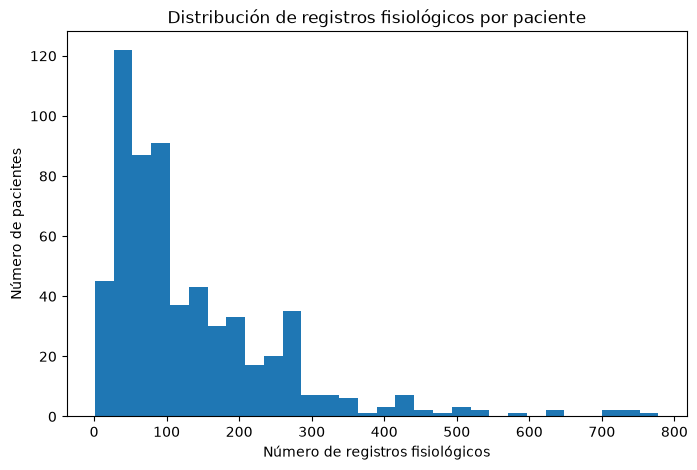

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    records_per_patient,
    bins=30
)

plt.xlabel("Número de registros fisiológicos")
plt.ylabel("Número de pacientes")
plt.title(
    "Distribución de registros fisiológicos por paciente"
)

plt.show()

### Diagrama de caja del número de registros por paciente

El diagrama de caja permite visualizar la mediana, los cuartiles, la dispersión
y la presencia potencial de valores extremos en el número de registros
fisiológicos disponibles por paciente.

/var/folders/bv/hf85_zp55q1g6zv69_qdp7vm0000gn/T/ipykernel_33340/3468001742.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


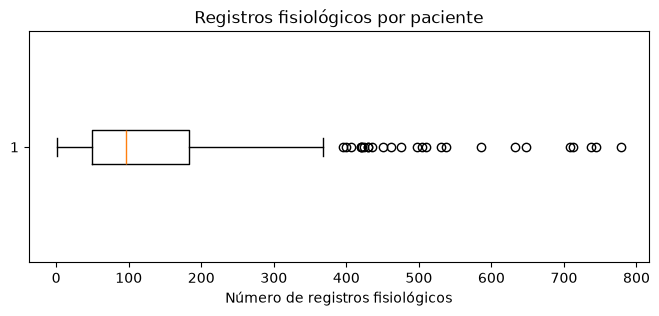

In [ ]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    records_per_patient,
    vert=False
)

plt.xlabel("Número de registros fisiológicos")
plt.title(
    "Registros fisiológicos por paciente"
)

plt.show()

### Disponibilidad de registros EEG por paciente

Debido a que el EEG constituye la principal modalidad de interés para el
análisis posterior de señales, su disponibilidad se estudia de manera
independiente.

Se determina el número total de registros EEG, la cantidad de pacientes con
EEG disponible y la existencia de pacientes sin registros EEG.

In [ ]:
eeg_df = records_df[
    records_df["Modality"] == "EEG"
].copy()

print(
    "Total de registros EEG:",
    len(eeg_df)
)

print(
    "Pacientes con EEG:",
    eeg_df["Patient"].nunique()
)

print(
    "Pacientes sin EEG:",
    records_df["Patient"].nunique()
    - eeg_df["Patient"].nunique()
)

Total de registros EEG: 36123
Pacientes con EEG: 607
Pacientes sin EEG: 0


### Disponibilidad de EEG en la cohorte

Se identificaron **36.123 registros EEG** correspondientes a los **607
pacientes** incluidos en el inventario.

Todos los pacientes presentan al menos un registro EEG disponible, por lo que
no se identificaron pacientes sin disponibilidad de EEG a nivel del inventario.

Este resultado describe únicamente la **disponibilidad de registros**. No
implica que todos los pacientes tengan la misma cantidad, duración, número de
canales o calidad de señal, aspectos que serán evaluados posteriormente.

### Número de registros EEG por paciente

Se calcula el número de registros EEG disponibles para cada paciente. Esta
variable permite estudiar la heterogeneidad en la cantidad de registros EEG
dentro de la cohorte.

In [ ]:
eeg_per_patient = (
    eeg_df
    .groupby("Patient")
    .size()
    .rename("EEG_records")
)

eeg_per_patient.head(10)

Patient
0284    85
0286    63
0296     6
0299    30
0303    46
0306    46
0311    18
0312    53
0313    41
0316    77
Name: EEG_records, dtype: int64

### Estadísticas descriptivas de la disponibilidad de EEG

Se calculan estadísticas descriptivas sobre el número de registros EEG por
paciente, incluyendo media, desviación estándar, mínimo, cuartiles, mediana
y máximo.

In [ ]:
eeg_per_patient.describe()

count    607.000000
mean      59.510708
std       43.509865
min        1.000000
25%       30.000000
50%       49.000000
75%       77.500000
max      389.000000
Name: EEG_records, dtype: float64

### Distribución del número de registros EEG por paciente

El histograma permite examinar la distribución del número de registros EEG
disponibles por paciente y detectar posibles concentraciones, asimetrías o
diferencias importantes en la disponibilidad de EEG dentro de la cohorte.

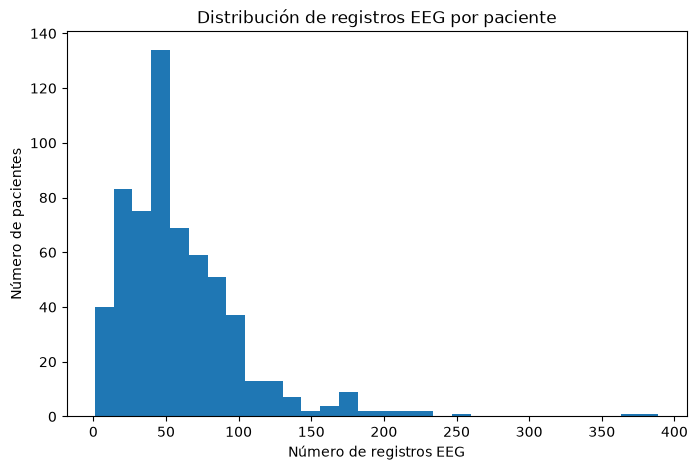

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    eeg_per_patient,
    bins=30
)

plt.xlabel("Número de registros EEG")
plt.ylabel("Número de pacientes")
plt.title(
    "Distribución de registros EEG por paciente"
)

plt.show()

### Diagrama de caja del número de registros EEG por paciente

El diagrama de caja complementa el análisis de distribución mostrando la
mediana, los cuartiles, la dispersión y posibles valores extremos en la
cantidad de registros EEG disponibles por paciente.

/var/folders/bv/hf85_zp55q1g6zv69_qdp7vm0000gn/T/ipykernel_33340/1007537849.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


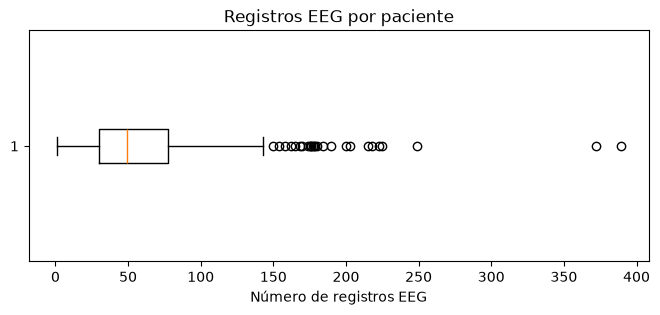

In [ ]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    eeg_per_patient,
    vert=False
)

plt.xlabel("Número de registros EEG")
plt.title(
    "Registros EEG por paciente"
)

plt.show()

### Análisis de metadatos de los encabezados EEG (`.hea`)

Una vez caracterizada la disponibilidad de los registros EEG, se analizan
los metadatos contenidos en sus archivos de encabezado (`.hea`).

El objetivo es describir propiedades estructurales de las señales EEG sin
necesidad de descargar inicialmente todos los archivos de señal (`.mat`).

Las principales variables de interés son:

- Frecuencia de muestreo.
- Número de canales.
- Nombres de los canales.
- Número de muestras.
- Duración del registro.

In [ ]:
import wfdb

record_path = patient_eeg_dir / record_name

header = wfdb.rdheader(
    str(record_path)
)

print("Registro:", record_name)
print("Frecuencia de muestreo:", header.fs, "Hz")
print("Número de canales:", header.n_sig)
print("Número de muestras:", header.sig_len)
print("Duración:", header.sig_len / header.fs, "segundos")
print("Canales:")
print(header.sig_name)

Registro: 0284_001_004_EEG
Frecuencia de muestreo: 500 Hz
Número de canales: 19
Número de muestras: 1578500
Duración: 3157.0 segundos
Canales:
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


### Interpretación de un encabezado EEG

El archivo `.hea` contiene información estructural sobre el registro sin
contener directamente las muestras completas de la señal.

La duración del registro puede calcularse como:

$$
T = \frac{N}{f_s}
$$

donde:

- $N$ es el número de muestras.
- $f_s$ es la frecuencia de muestreo en Hz.
- $T$ es la duración del registro en segundos.

### Construcción del inventario global de metadatos EEG

Después de validar la lectura de un archivo de encabezado EEG, el procedimiento
se extiende a todos los registros EEG identificados en el inventario.

En esta etapa se consultan únicamente los archivos `.hea`. Los archivos `.mat`,
que contienen las muestras completas de las señales, no se descargan.

Para cada registro EEG se extraen las siguientes características:

- Identificador del paciente.
- Identificador del registro.
- Frecuencia de muestreo.
- Número de canales.
- Número de muestras.
- Duración del registro en segundos.
- Nombres de los canales.

El resultado se almacena en un nuevo conjunto de datos denominado
`eeg_headers_df`, donde cada fila representa un registro EEG.

In [ ]:
eeg_headers = []

for i, row in eeg_df.iterrows():

    patient_id = row["Patient"]
    record_name = row["Record"]

    header_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/{record_name}.hea"
    )

    response = requests.get(header_url)
    response.raise_for_status()

    lines = response.text.strip().splitlines()

    # First line of the WFDB header
    first_line = lines[0].split()

    record = first_line[0]
    n_channels = int(first_line[1])
    sampling_frequency = float(first_line[2])
    n_samples = int(first_line[3])

    duration_seconds = (
        n_samples / sampling_frequency
    )

    # Channel names are found at the end
    # of the following n_channels lines
    channel_names = [
        line.split()[-1]
        for line in lines[1:1 + n_channels]
    ]

    eeg_headers.append({
        "Patient": patient_id,
        "Record": record_name,
        "SamplingFrequency": sampling_frequency,
        "Channels": n_channels,
        "Samples": n_samples,
        "DurationSeconds": duration_seconds,
        "ChannelNames": channel_names
    })

    if (i + 1) % 1000 == 0:
        print(f"Procesados: {i + 1}")

Procesados: 7000


## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    
**Universidad Nacional de Colombia** - *Facultad de Ingeniería*